für Erreichbarkeitsanalysen zunächst Wegenetz jeder Stadt laden


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install osmnx

#OSMnx graph files erstellen

In [ ]:
import osmnx as ox
import os

# List of cities to download
cities = [
    "Aschaffenburg",
    "Augsburg",
    "Bamberg",
    "Bayreuth",
    "Erlangen",
    "Fürth",
    "Ingolstadt",
    "Kempten (Allgäu)",
    "Landshut",
    "Munich",
    "Nuremberg",
    "Passau",
    "Regensburg",
    "Rosenheim",
    "Schweinfurt",
    "Würzburg"
]

# Directory to save the graphml files
output_dir = "/content/drive/MyDrive/Cold Spots Bayern/OSMnx_Wegegraphen"
os.makedirs(output_dir, exist_ok=True)

# Download and save the street networks
for city in cities:
    print(f"Downloading street network for {city}...")
    try:
        G = ox.graph_from_place(city, network_type="walk")
        filepath = os.path.join(output_dir, f"{city.replace(' ', '_')}_walk.graphml")
        ox.save_graphml(G, filepath)
        print(f"Saved street network for {city} to {filepath}")
    except Exception as e:
        print(f"Could not download or save street network for {city}: {e}")

print("Finished downloading and saving street networks.")

Saved street network for Aschaffenburg to /content/drive/MyDrive/Cold Spots Bayern/OSMnx_Wegegraphen/Aschaffenburg_walk.graphml
Saved street network for Augsburg to /content/drive/MyDrive/Cold Spots Bayern/OSMnx_Wegegraphen/Augsburg_walk.graphml
Saved street network for Bamberg to /content/drive/MyDrive/Cold Spots Bayern/OSMnx_Wegegraphen/Bamberg_walk.graphml
Saved street network for Bayreuth to /content/drive/MyDrive/Cold Spots Bayern/OSMnx_Wegegraphen/Bayreuth_walk.graphml
Saved street network for Erlangen to /content/drive/MyDrive/Cold Spots Bayern/OSMnx_Wegegraphen/Erlangen_walk.graphml
Saved street network for Fürth to /content/drive/MyDrive/Cold Spots Bayern/OSMnx_Wegegraphen/Fürth_walk.graphml
Saved street network for Ingolstadt to /content/drive/MyDrive/Cold Spots Bayern/OSMnx_Wegegraphen/Ingolstadt_walk.graphml
Saved street network for Kempten (Allgäu) to /content/drive/MyDrive/Cold Spots Bayern/OSMnx_Wegegraphen/Kempten_(Allgäu)_walk.graphml
Saved street network for Landshut 

##gespeicherte Daten wieder ins Notebook laden

In [ ]:
import osmnx as ox
import os

# Directory where the graphml files are saved
output_dir = "/content/drive/MyDrive/Cold Spots Bayern/OSMnx_Wegegraphen"

# List to store the loaded graphs
graphs = {}

# Load the street networks from the graphml files
for filename in os.listdir(output_dir):
    if filename.endswith("_walk.graphml"):
        city_name = filename.replace("_walk.graphml", "").replace("_", " ")
        filepath = os.path.join(output_dir, filename)
        print(f"Loading street network for {city_name} from {filepath}...")
        try:
            G = ox.load_graphml(filepath)
            graphs[city_name] = G
            print(f"Loaded street network for {city_name}")
        except Exception as e:
            print(f"Could not load street network for {city_name}: {e}")

print("Finished loading street networks.")

# You can now access the graphs for each city using the 'graphs' dictionary
# For example, to access the graph for Munich:
# munich_graph = graphs["Munich"]

Loading street network for Aschaffenburg from /content/drive/MyDrive/Cold Spots Bayern/OSMnx_Wegegraphen/Aschaffenburg_walk.graphml...


KeyboardInterrupt: 

In [ ]:
import osmnx as ox

# Dictionary für reprojizierte Graphen
graphs_proj = {}

# Alle Graphen in EPSG:32632 projizieren und speichern
for city, G in graphs.items():
    if G.graph.get("crs") != "epsg:32632":
        print(f"Projecting {city} to EPSG:32632...")
        graphs_proj[city] = ox.project_graph(G, to_crs="epsg:32632")
    else:
        graphs_proj[city] = G
        print(f"{city} is already in EPSG:32632")

print("\nFinished projecting all graphs.")


##projizierte Graph-Dateien speichern und wieder laden

In [ ]:
import osmnx as ox
import os

# Define the directory to save the projected graphml files in Google Drive
output_dir_proj = "/content/drive/MyDrive/Cold Spots Bayern/OSMnx_Graphen_proj"
os.makedirs(output_dir_proj, exist_ok=True)

print(f"Saving projected graphs to: {output_dir_proj}")

# Save the projected street networks
for city_name, G_proj in graphs_proj.items():
    print(f"Saving projected street network for {city_name}...")
    try:
        # Create a safe filename
        safe_city_name = city_name.replace(" ", "_").replace("(", "").replace(")", "").replace("̈", "e").replace("ä", "ae").replace("ö", "oe").replace("ü", "ue")
        filepath = os.path.join(output_dir_proj, f"{safe_city_name}_walk_proj.graphml")
        ox.save_graphml(G_proj, filepath)
        print(f"  Saved projected street network for {city_name} to {filepath}")
    except Exception as e:
        print(f"  Could not save projected street network for {city_name}: {e}")

print("\nFinished saving projected street networks.")

Saving projected graphs to: /content/drive/MyDrive/Cold Spots Bayern/OSMnx_Graphen_proj


NameError: name 'graphs_proj' is not defined

In [3]:
import osmnx as ox
import os

# Define the directory where the projected graphml files are saved in Google Drive
input_dir_proj = "/content/drive/MyDrive/Cold Spots Bayern/OSMnx_Graphen_proj"

# Initialize a dictionary to store the loaded projected graphs
graphs_proj = {}

print(f"Loading projected graphs from: {input_dir_proj}")

# Load the projected street networks from the graphml files
if os.path.exists(input_dir_proj):
    for filename in os.listdir(input_dir_proj):
        if filename.endswith("_walk_proj.graphml"):
            # Extract city name from filename
            city_name = filename.replace("_walk_proj.graphml", "").replace("_", " ")
            # Handle specific city name variations if necessary to match original keys if needed later
            city_name = city_name.replace("Fuerth", "Fürth").replace("Wuerzburg", "Würzburg").replace("Kempten Allgaeu", "Kempten (Allgäu)")

            filepath = os.path.join(input_dir_proj, filename)
            print(f"Loading projected street network for {city_name} from {filepath}...")
            try:
                G_proj = ox.load_graphml(filepath)
                graphs_proj[city_name] = G_proj
                print(f"Loaded projected street network for {city_name}")
            except Exception as e:
                print(f"Could not load projected street network for {city_name}: {e}")
else:
    print(f"Directory not found: {input_dir_proj}")

print("\nFinished loading projected street networks.")

# The 'graphs_proj_loaded' dictionary now contains the loaded projected graphs.
# You may want to rename it to 'graphs_proj' to overwrite the current variable
# if you intend to continue using the same variable name:
# graphs_proj = graphs_proj_loaded

Loading projected graphs from: /content/drive/MyDrive/Cold Spots Bayern/OSMnx_Graphen_proj
Loading projected street network for Aschaffenburg from /content/drive/MyDrive/Cold Spots Bayern/OSMnx_Graphen_proj/Aschaffenburg_walk_proj.graphml...
Loaded projected street network for Aschaffenburg
Loading projected street network for Augsburg from /content/drive/MyDrive/Cold Spots Bayern/OSMnx_Graphen_proj/Augsburg_walk_proj.graphml...
Loaded projected street network for Augsburg
Loading projected street network for Bamberg from /content/drive/MyDrive/Cold Spots Bayern/OSMnx_Graphen_proj/Bamberg_walk_proj.graphml...
Loaded projected street network for Bamberg
Loading projected street network for Bayreuth from /content/drive/MyDrive/Cold Spots Bayern/OSMnx_Graphen_proj/Bayreuth_walk_proj.graphml...
Loaded projected street network for Bayreuth
Loading projected street network for Erlangen from /content/drive/MyDrive/Cold Spots Bayern/OSMnx_Graphen_proj/Erlangen_walk_proj.graphml...
Loaded proje

#Cold Spots laden
- 2024
- 2019-2024

Cold Spots wurden bereits zu Polygonen umgewandelt und bei Überlappungen gruppiert

beim laden jetzt nur die Cold Spots mit p<=0,01 in dictionary laden

##Cold Spots 2019-2024 laden

In [ ]:
import geopandas as gpd
import os

# Define the base directory in Google Drive where the Cold Spot results are saved
# Updated input directory based on user request
input_dir = "/content/drive/MyDrive/Cold Spots Bayern/Gi_Ergebnisse_2019_2024_Puffer_gefiltert"

# Initialize a dictionary to store the loaded and filtered Cold Spot geodataframes (p<=0.01)
loaded_cold_spots_2019_2024_p001 = {}

print(f"Lade Cold Spots (p<=0.01) aus dem Ordner: {input_dir}")

# Load Cold Spots from .gpkg files and filter for p<=0.01
if os.path.exists(input_dir):
    for filename in os.listdir(input_dir):
        # Check for .gpkg files
        if filename.endswith(".gpkg"):
            file_path = os.path.join(input_dir, filename)
            try:
                # Read the geodatabase file
                gdf = gpd.read_file(file_path)

                # Extract city name from filename (remove "_cold_spots_2024_filtered.gpkg" and replace underscores with spaces)
                # Assuming a consistent filename format like "CityName_cold_spots_2024_filtered.gpkg"
                city_name = filename.replace("_cold_spots_2024_filtered.gpkg", "").replace("_", " ")

                # Handle the umlaut and special characters in city names if necessary
                # This part might need adjustment based on the exact filenames, but keeping the previous logic
                city_name = city_name.replace("ae", "ä").replace("oe", "ö").replace("ue", "ü").replace("Ue", "Ü")
                city_name = city_name.replace("Kempten Allgaeu", "Kempten (Allgäu)") # Specific handling for Kempten
                # Add more replacements if needed based on actual filenames

                # Filter the GeoDataFrame to keep only rows where the p-value in 'gi_star_p_sim' is <= 0.01
                # Assuming 'gi_star_p_sim' is a numeric column representing the p-value.
                if 'gi_star_p_sim' in gdf.columns:
                    filtered_gdf = gdf[gdf['gi_star_p_sim'] <= 0.01].copy() # Use .copy() to avoid SettingWithCopyWarning
                else:
                    print(f"  Warnung: Spalte 'gi_star_p_sim' nicht in {filename} gefunden. Überspringe Filterung für diese Datei.")
                    filtered_gdf = gpd.GeoDataFrame(geometry=[], crs=gdf.crs) # Create empty if column is missing


                # Check if the filtered geodataframe is not empty before storing
                if not filtered_gdf.empty:
                    loaded_cold_spots_2019_2024_p001[city_name] = filtered_gdf
                    print(f"  Geladen und gefiltert: {filename} ({city_name}) - {len(filtered_gdf)} Cold Spots (p<=0.01)")
                else:
                    print(f"  Geladen und gefiltert: {filename} ({city_name}) - Keine Cold Spots mit p<=0.01 gefunden.")

            except Exception as e:
                print(f"  Fehler beim Laden oder Filtern von {filename}: {e}")
else:
    print(f"  Ordner nicht gefunden: {input_dir}")


print("\nLaden und Filtern der Cold Spot Ergebnisse (p<=0.01) 2019-2024 abgeschlossen.")

# The 'loaded_cold_spots_p001' dictionary now contains the loaded and filtered cold spot geodataframes for p<=0.01
# You can now access the loaded cold spot geodataframes using the dictionary
# For example: munich_cold_spots_p001 = loaded_cold_spots_p001['Munich']

Lade Cold Spots (p<=0.01) aus dem Ordner: /content/drive/MyDrive/Cold Spots Bayern/Gi_Ergebnisse_2019_2024_Puffer_gefiltert
  Geladen und gefiltert: Aschaffenburg_2019_2024_cold_spots_combined_2019_2024.gpkg (Aschaffenburg 2019 2024 cold spots combined 2019 2024.gpkg) - 21594 Cold Spots (p<=0.01)
  Geladen und gefiltert: Augsburg_2019_2024_cold_spots_combined_2019_2024.gpkg (Augsburg 2019 2024 cold spots combined 2019 2024.gpkg) - 42031 Cold Spots (p<=0.01)
  Geladen und gefiltert: Bamberg_2019_2024_cold_spots_combined_2019_2024.gpkg (Bamberg 2019 2024 cold spots combined 2019 2024.gpkg) - 40255 Cold Spots (p<=0.01)
  Geladen und gefiltert: Bayreuth_2019_2024_cold_spots_combined_2019_2024.gpkg (Bayreuth 2019 2024 cold spots combined 2019 2024.gpkg) - 46846 Cold Spots (p<=0.01)
  Geladen und gefiltert: Erlangen_2019_2024_cold_spots_combined_2019_2024.gpkg (Erlangen 2019 2024 cold spots combined 2019 2024.gpkg) - 30386 Cold Spots (p<=0.01)
  Geladen und gefiltert: Fürth_2019_2024_cold_s

überprüfen, welche geometrie die Cold Spot Daten haben

In [ ]:
import geopandas as gpd

print("\nChecking geometry types for loaded Cold Spot data (2019-2024, p<=0.01):")
if loaded_cold_spots_2019_2024_p001:
    # Get the first GeoDataFrame in the dictionary
    first_city_name_2019_2024 = list(loaded_cold_spots_2019_2024_p001.keys())[0]
    first_gdf_2019_2024 = loaded_cold_spots_2019_2024_p001[first_city_name_2019_2024]
    if not first_gdf_2019_2024.empty:
        print(f"  Geometry type for {first_city_name_2019_2024}: {first_gdf_2019_2024.geometry.iloc[0].geom_type}")
    else:
         print(f"  GeoDataFrame for {first_city_name_2019_2024} is empty.")
else:
    print("  No Cold Spot data loaded for 2019-2024 (p<=0.01).")

Checking geometry types for loaded Cold Spot data (2024, p<=0.01):
  Geometry type for Bayreuth cold spots combined 2024.gpkg: Polygon

Checking geometry types for loaded Cold Spot data (2019-2024, p<=0.01):
  Geometry type for Aschaffenburg 2019 2024 cold spots combined 2019 2024.gpkg: Polygon


als **Startpunkte für Erreichbarkeitsanalyse** sollen "äußerste" Punkte der Cold Spots gefunden werden

=> alle Schnittpunkte zwischen Straßen (edges) der Wegenetze, und Cold Spot-Außenlinien (dafür braucht es Cold Spot Polygone) finden und als Startpunkte festlegen

wenn keine Schnittpunkte mit der Außenlinie, dann von Mittelpunkt des Cold Spots aus einen größeren kreisrunden Puffer, vllt. 50 Meter ziehen, und Schnittpunkte in diesem Bereich wählen

## Polygone in Linien umwandeln

In [ ]:
import geopandas as gpd

# Dictionary to store the resulting boundary GeoDataFrames for each city for 2024 data
cold_spot_boundaries_2019_2024_p001 = {}

# Dictionary to store the resulting boundary GeoDataFrames for each city for 2019-2024 data
#cold_spot_boundaries_2019_2024_p001 = {}


# Convert polygons to boundaries for each city for 2024 data
print("Converting polygons to boundaries for 2019- 2024 data...")
for city_name, gdf_polygons in loaded_cold_spots_2019_2024_p001.items():
    try:
        # Get the boundary of each polygon
        gdf_boundaries = gdf_polygons.copy() # Create a copy to avoid modifying the original data
        gdf_boundaries['geometry'] = gdf_boundaries.geometry.boundary

        # The boundary operation might result in MultiLineStrings, explode them into single LineStrings
        gdf_boundaries = gdf_boundaries.explode(index_parts=True)

        cold_spot_boundaries_2019_2024_p001[city_name] = gdf_boundaries
        print(f"Converted polygons to boundaries for {city_name} (2019-2024)")
    except Exception as e:
        print(f"Could not convert polygons to boundaries for {city_name} (2019-2024): {e}")

print("\nFinished converting polygons to boundaries for 2019-2024 data.")


# Convert polygons to boundaries for each city for 2019-2024 data
#print("\nConverting polygons to boundaries for 2019-2024 data...")
#for city_name, gdf_polygons in loaded_cold_spots_2019_2024_p001.items():
    #try:
        # Get the boundary of each polygon
        #gdf_boundaries = gdf_polygons.copy() # Create a copy to avoid modifying the original data
        #gdf_boundaries['geometry'] = gdf_boundaries.geometry.boundary

        # The boundary operation might result in MultiLineStrings, explode them into single LineStrings
        #gdf_boundaries = gdf_boundaries.explode(index_parts=True)

        #cold_spot_boundaries_2019_2024_p001[city_name] = gdf_boundaries
        #print(f"Converted polygons to boundaries for {city_name} (2019-2024)")
    #except Exception as e:
        #print(f"Could not convert polygons to boundaries for {city_name} (2019-2024): {e}")

#print("\nFinished converting polygons to boundaries for 2019-2024 data.")

# You can now access the boundary geodataframes using the 'cold_spot_boundaries_2024_p001' and 'cold_spot_boundaries_2019_2024_p001' dictionaries

Converting polygons to boundaries for 2019- 2024 data...
Converted polygons to boundaries for Aschaffenburg 2019 2024 cold spots combined 2019 2024.gpkg (2019-2024)
Converted polygons to boundaries for Augsburg 2019 2024 cold spots combined 2019 2024.gpkg (2019-2024)
Converted polygons to boundaries for Bamberg 2019 2024 cold spots combined 2019 2024.gpkg (2019-2024)
Converted polygons to boundaries for Bayreuth 2019 2024 cold spots combined 2019 2024.gpkg (2019-2024)
Converted polygons to boundaries for Erlangen 2019 2024 cold spots combined 2019 2024.gpkg (2019-2024)
Converted polygons to boundaries for Fürth 2019 2024 cold spots combined 2019 2024.gpkg (2019-2024)
Converted polygons to boundaries for Ingolstadt 2019 2024 cold spots combined 2019 2024.gpkg (2019-2024)
Converted polygons to boundaries for Kempten (Allgäu) 2019 2024 cold spots combined 2019 2024.gpkg (2019-2024)
Converted polygons to boundaries for Landshut 2019 2024 cold spots combined 2019 2024.gpkg (2019-2024)
Con

# Schnittpunkte der Cold Spots mit Graphen finden

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import osmnx as ox

# Dictionaries für Ergebnisse
#intersection_points_2024 = {}
intersection_points_2019_2024 = {}

def compute_intersections(city_name, cold_spot_dict, year_label):
    print(f"\nProcessing {city_name} ({year_label})...")

    cold_spot_key = [k for k in cold_spot_dict.keys() if k.startswith(city_name)]
    if not cold_spot_key:
        print(f"  Skipping {city_name}: keine passenden Cold-Spot-Daten in {year_label}.")
        return gpd.GeoDataFrame(geometry=[], crs="epsg:32632")

    cold_spot_key = cold_spot_key[0]
    cold_spots_gdf = cold_spot_dict[cold_spot_key]

    G_proj = graphs_proj[city_name]
    edges_gdf = ox.graph_to_gdfs(G_proj, nodes=False, edges=True)

    if cold_spots_gdf.crs != edges_gdf.crs:
        cold_spots_gdf = cold_spots_gdf.to_crs(edges_gdf.crs)

    # Overlay, aber Geometrietypen nicht filtern
    print(f"  Berechne Overlay für {city_name} ({year_label})...")
    intersections = gpd.overlay(edges_gdf, cold_spots_gdf, how="intersection", keep_geom_type=False)

    # Nur Punkte behalten
    intersections = intersections[intersections.geometry.type.isin(["Point", "MultiPoint"])]

    if not intersections.empty:
        intersections = intersections.explode(ignore_index=True)

    print(f"  -> Gefundene Schnittpunkte: {len(intersections)}")
    return intersections



# Alle Städte durchlaufen
for city_name in graphs_proj.keys():
    # 2024
    #intersection_points_2024[city_name] = compute_intersections(
        #city_name, cold_spot_boundaries_2024_p001, "2024"
    #)

    # 2019–2024
    intersection_points_2019_2024[city_name] = compute_intersections(
        city_name, cold_spot_boundaries_2019_2024_p001, "2019–2024"
    )

print("\nFertig! Alle Schnittpunkte berechnet.")



Processing Aschaffenburg (2019–2024)...
  Berechne Overlay für Aschaffenburg (2019–2024)...
  -> Gefundene Schnittpunkte: 62472

Processing Augsburg (2019–2024)...
  Berechne Overlay für Augsburg (2019–2024)...
  -> Gefundene Schnittpunkte: 161376

Processing Bamberg (2019–2024)...
  Berechne Overlay für Bamberg (2019–2024)...
  -> Gefundene Schnittpunkte: 135738

Processing Bayreuth (2019–2024)...
  Berechne Overlay für Bayreuth (2019–2024)...
  -> Gefundene Schnittpunkte: 157920

Processing Erlangen (2019–2024)...
  Berechne Overlay für Erlangen (2019–2024)...
  -> Gefundene Schnittpunkte: 141200

Processing Fürth (2019–2024)...
  Berechne Overlay für Fürth (2019–2024)...
  -> Gefundene Schnittpunkte: 105624

Processing Ingolstadt (2019–2024)...
  Berechne Overlay für Ingolstadt (2019–2024)...
  -> Gefundene Schnittpunkte: 105766

Processing Kempten (Allgäu) (2019–2024)...
  Berechne Overlay für Kempten (Allgäu) (2019–2024)...
  -> Gefundene Schnittpunkte: 45832

Processing Land

### Schnittpunke (intersection points) in Drive speichern

In [ ]:
import os
import geopandas as gpd

# Define output directories
#output_dir_2024 = '/content/intersection_points_2024'
output_dir_2019_2024 = '/content/drive/MyDrive/Cold Spots Bayern/intersection_points_2019_2024'

# Create output directories if they don't exist
#os.makedirs(output_dir_2024, exist_ok=True)
os.makedirs(output_dir_2019_2024, exist_ok=True)

print("Saving intersection points for 2024...")
# Save 2024 intersection points
#for city_name, intersection_gdf in intersection_points_2024.items():
    #if not intersection_gdf.empty:
        # Create a safe filename
        #safe_city_name = city_name.replace(" ", "_").replace("(", "").replace(")", "").replace("̈", "e").replace("ä", "ae").replace("ö", "oe").replace("ü", "ue")
        #filepath = os.path.join(output_dir_2024, f'{safe_city_name}_intersection_points_2024.gpkg')
        #try:
            #intersection_gdf.to_file(filepath, driver='GPKG')
            #print(f"  Saved {city_name} 2024 intersection points to {filepath}")
       # except Exception as e:
            #print(f"  Error saving {city_name} 2024 intersection points: {e}")
    #else:
       # print(f"  No 2024 intersection points to save for {city_name}")

print("\nSaving intersection points for 2019-2024...")
# Save 2019-2024 intersection points
for city_name, intersection_gdf in intersection_points_2019_2024.items():
    if not intersection_gdf.empty:
        # Create a safe filename
        safe_city_name = city_name.replace(" ", "_").replace("(", "").replace(")", "").replace("̈", "e").replace("ä", "ae").replace("ö", "oe").replace("ü", "ue")
        filepath = os.path.join(output_dir_2019_2024, f'{safe_city_name}_intersection_points_2019_2024.gpkg')
        try:
            intersection_gdf.to_file(filepath, driver='GPKG')
            print(f"  Saved {city_name} 2019-2024 intersection points to {filepath}")
        except Exception as e:
            print(f"  Error saving {city_name} 2019-2024 intersection points: {e}")
    else:
        print(f"  No 2019-2024 intersection points to save for {city_name}")

print("\nFinished saving intersection points.")

Saving intersection points for 2024...

Saving intersection points for 2019-2024...
  Saved Aschaffenburg 2019-2024 intersection points to /content/intersection_points_2019_2024/Aschaffenburg_intersection_points_2019_2024.gpkg
  Saved Augsburg 2019-2024 intersection points to /content/intersection_points_2019_2024/Augsburg_intersection_points_2019_2024.gpkg
  Saved Bamberg 2019-2024 intersection points to /content/intersection_points_2019_2024/Bamberg_intersection_points_2019_2024.gpkg
  Saved Bayreuth 2019-2024 intersection points to /content/intersection_points_2019_2024/Bayreuth_intersection_points_2019_2024.gpkg
  Saved Erlangen 2019-2024 intersection points to /content/intersection_points_2019_2024/Erlangen_intersection_points_2019_2024.gpkg
  Saved Fürth 2019-2024 intersection points to /content/intersection_points_2019_2024/Fuerth_intersection_points_2019_2024.gpkg
  Saved Ingolstadt 2019-2024 intersection points to /content/intersection_points_2019_2024/Ingolstadt_intersection

##intersection points aus drive laden

In [4]:
import os
import geopandas as gpd

# Define the directories where the intersection points are saved
#input_dir_2024 = '/content/intersection_points_2024'
input_dir_2019_2024 = '/content/drive/MyDrive/Cold Spots Bayern/intersection_points_2019_2024'

# Initialize dictionaries to store the loaded intersection points
#intersection_points_2024 = {}
intersection_points_2019_2024 = {}

#print("Loading intersection points for 2024...")
# Load 2024 intersection points
#if os.path.exists(input_dir_2024):
    #for filename in os.listdir(input_dir_2024):
        #if filename.endswith(".gpkg"):
            #filepath = os.path.join(input_dir_2024, filename)
            #try:
                # Read the GeoPackage file
                #intersection_gdf = gpd.read_file(filepath)
                # Extract city name from filename (remove "_intersection_points_2024.gpkg" and replace underscores with spaces)
                #city_name = filename.replace("_intersection_points_2024.gpkg", "").replace("_", " ")
                 # Handle potential name variations (e.g., umlauts) if necessary to match graph keys
                #city_name = city_name.replace("Fuerth", "Fürth").replace("Wuerzburg", "Würzburg").replace("Kempten Allgaeu", "Kempten (Allgäu)")

                #intersection_points_2024[city_name] = intersection_gdf
                #print(f"  Loaded {city_name} 2024 intersection points from {filepath}")
            #except Exception as e:
                #print(f"  Error loading {filename}: {e}")
#else:
    #print(f"  Directory not found: {input_dir_2024}")

print("\nLoading intersection points for 2019-2024...")
# Load 2019-2024 intersection points
if os.path.exists(input_dir_2019_2024):
    for filename in os.listdir(input_dir_2019_2024):
        if filename.endswith(".gpkg"):
            filepath = os.path.join(input_dir_2019_2024, filename)
            try:
                # Read the GeoPackage file
                intersection_gdf = gpd.read_file(filepath)
                # Extract city name from filename (remove "_intersection_points_2019_2024.gpkg" and replace underscores with spaces)
                city_name = filename.replace("_intersection_points_2019_2024.gpkg", "").replace("_", " ")
                # Handle potential name variations (e.g., umlauts) if necessary to match graph keys
                city_name = city_name.replace("Fuerth", "Fürth").replace("Wuerzburg", "Würzburg").replace("Kempten Allgaeu", "Kempten (Allgäu)")

                intersection_points_2019_2024[city_name] = intersection_gdf
                print(f"  Loaded {city_name} 2019-2024 intersection points from {filepath}")
            except Exception as e:
                print(f"  Error loading {filename}: {e}")
else:
    print(f"  Directory not found: {input_dir_2019_2024}")

print("\nFinished loading intersection points.")

# The 'loaded_intersection_points_2024' and 'loaded_intersection_points_2019_2024' dictionaries
# now contain the loaded intersection points. You can rename them to 'intersection_points_2024'
# and 'intersection_points_2019_2024' if you want to overwrite the current variables.
# Example:
# intersection_points_2024 = loaded_intersection_points_2024
# intersection_points_2019_2024 = loaded_intersection_points_2019_2024


Loading intersection points for 2019-2024...
  Loaded Aschaffenburg 2019-2024 intersection points from /content/drive/MyDrive/Cold Spots Bayern/intersection_points_2019_2024/Aschaffenburg_intersection_points_2019_2024.gpkg
  Loaded Augsburg 2019-2024 intersection points from /content/drive/MyDrive/Cold Spots Bayern/intersection_points_2019_2024/Augsburg_intersection_points_2019_2024.gpkg
  Loaded Bamberg 2019-2024 intersection points from /content/drive/MyDrive/Cold Spots Bayern/intersection_points_2019_2024/Bamberg_intersection_points_2019_2024.gpkg
  Loaded Bayreuth 2019-2024 intersection points from /content/drive/MyDrive/Cold Spots Bayern/intersection_points_2019_2024/Bayreuth_intersection_points_2019_2024.gpkg
  Loaded Erlangen 2019-2024 intersection points from /content/drive/MyDrive/Cold Spots Bayern/intersection_points_2019_2024/Erlangen_intersection_points_2019_2024.gpkg
  Loaded Fürth 2019-2024 intersection points from /content/drive/MyDrive/Cold Spots Bayern/intersection_po

In [9]:
print(intersection_points_2019_2024.keys())

dict_keys(['Aschaffenburg', 'Augsburg', 'Bamberg', 'Bayreuth', 'Erlangen', 'Fürth', 'Ingolstadt', 'Kempten (Allgäu)', 'Landshut', 'Munich', 'Nuremberg', 'Passau', 'Regensburg', 'Rosenheim', 'Schweinfurt', 'Würzburg'])


In [7]:
for city, gdf in intersection_points_2019_2024.items():
    print(f"{city}: {len(gdf)} intersection Points")

Aschaffenburg: 62472 intersection Points
Augsburg: 161376 intersection Points
Bamberg: 135738 intersection Points
Bayreuth: 157920 intersection Points
Erlangen: 141200 intersection Points
Fürth: 105624 intersection Points
Ingolstadt: 105766 intersection Points
Kempten (Allgäu): 45832 intersection Points
Landshut: 135832 intersection Points
Munich: 725660 intersection Points
Nuremberg: 297682 intersection Points
Passau: 38312 intersection Points
Regensburg: 203058 intersection Points
Rosenheim: 46800 intersection Points
Schweinfurt: 52314 intersection Points
Würzburg: 126028 intersection Points


# Fallback-Startpunkte finden

Ersatzstartpunkte für die Cold-Spot Polygone, bei denen keine Überschneidung gefunden wurden => dafür: nearest node (Knotenpunkt/Kreuzung), ausgehend vom Mittelpunkt des Cold Spots finden und als fallback_point speichern

## Polygone ohne intersection points finden


In [ ]:
import geopandas as gpd

# Dictionaries to store the group_ids and the actual polygons without intersections for each time period
polygons_without_intersections_group_ids_2024 = {}
polygons_without_intersections_gdf_2024 = {}

polygons_without_intersections_group_ids_2019_2024 = {}
polygons_without_intersections_gdf_2019_2024 = {}


def identify_polygons_without_intersections(city_name, original_polygons_dict, intersection_points_dict, year_label, original_polygons_key_mapping):
    """Identifies original polygons that do not have corresponding intersection points based on group_id."""
    print(f"\nProcessing city for fallback logic ({year_label}): {city_name}")

    # Find the original polygon key using the provided mapping
    original_polygon_key = original_polygons_key_mapping.get(city_name)

    if original_polygon_key and original_polygon_key in original_polygons_dict:
        original_polygons_gdf = original_polygons_dict[original_polygon_key]
        print(f"  Accessed original cold spot polygons for {city_name} ({year_label}) using key: {original_polygon_key}")
    else:
        print(f"  Original cold spot polygons not found for {city_name} ({year_label}) based on mapping. Skipping.")
        return set(), gpd.GeoDataFrame(geometry=[], crs="epsg:32632") # Return empty sets and gdf


    # Access the intersection points for the city
    if city_name in intersection_points_dict and not intersection_points_dict[city_name].empty:
        intersection_gdf = intersection_points_dict[city_name]
        print(f"  Accessed intersection points for {city_name} ({year_label})")
        # Ensure the 'group_id' column exists in the intersection points GeoDataFrame
        if 'group_id' not in intersection_gdf.columns:
            print(f"  Error: 'group_id' column not found in intersection points for {city_name} ({year_label}). Cannot identify polygons without intersections.")
            return set(), gpd.GeoDataFrame(geometry=[], crs=original_polygons_gdf.crs) # Return empty sets and gdf

    else:
        print(f"  Intersection points not found or are empty for {city_name} ({year_label}). All original polygons will be considered without intersections.")
        # If no intersection points were found for this city/year, all original polygons need fallback
        original_group_ids = set(original_polygons_gdf['group_id'].unique())
        print(f"  Original group_ids count for {city_name} ({year_label}): {len(original_group_ids)}")
        return original_group_ids, original_polygons_gdf # Return all group_ids and the original gdf


    # Identify group_ids from the original polygons
    original_group_ids = set(original_polygons_gdf['group_id'].unique())
    print(f"  Original group_ids count for {city_name} ({year_label}): {len(original_group_ids)}")

    # Get the group_ids from the intersection points.
    # These are the group_ids of the cold spot boundaries that had intersections.
    group_ids_with_intersections = set(intersection_gdf['group_id'].unique())
    print(f"  Group_ids with intersections count (from intersection points) for {city_name} ({year_label}): {len(group_ids_with_intersections)}")


    # Find the group_ids from the original polygons that do not have any intersection points
    group_ids_without_intersections = original_group_ids - group_ids_with_intersections
    print(f"  Group_ids without intersections count for {city_name} ({year_label}): {len(group_ids_without_intersections)}")


    # Filter the original polygons GeoDataFrame to get the polygons without intersections
    polygons_without_intersections_gdf = original_polygons_gdf[
        original_polygons_gdf['group_id'].isin(group_ids_without_intersections)
    ].copy() # Use .copy()

    print(f"  Filtered original polygons for those without intersections for {city_name} ({year_label})")

    return group_ids_without_intersections, polygons_without_intersections_gdf


# Create mapping from city name (used in intersection_points dictionaries) to original polygon filename keys
original_polygons_key_mapping_2024 = {}
for key in loaded_cold_spots_2024_p001.keys():
     # Extract city name from the filename key (assuming format "CityName_...")
     #city_name_from_key = key.split('_')[0].replace(" cold spots combined 2024.gpkg", "") # Basic extraction, may need refinement
     # Refine extraction for known cities with variations
     if "Aschaffenburg" in key:
          city_name_from_key = "Aschaffenburg"
     elif "Augsburg" in key:
          city_name_from_key = "Augsburg"
     elif "Bamberg" in key:
          city_name_from_key = "Bamberg"
     elif "Bayreuth" in key:
          city_name_from_key = "Bayreuth"
     elif "Erlangen" in key:
          city_name_from_key = "Erlangen"
     elif "Fürth" in key: # Match the key used in graphs and intersection points
          city_name_from_key = "Fürth"
     elif "Ingolstadt" in key:
          city_name_from_key = "Ingolstadt"
     elif "Kempten (Allgäu)" in key: # Match the key used in graphs and intersection points
          city_name_from_key = "Kempten (Allgäu)"
     elif "Landshut" in key:
          city_name_from_key = "Landshut"
     elif "Munich" in key:
          city_name_from_key = "Munich"
     elif "Nuremberg" in key:
          city_name_from_key = "Nuremberg"
     elif "Passau" in key:
          city_name_from_key = "Passau"
     elif "Regensburg" in key:
          city_name_from_key = "Regensburg"
     elif "Rosenheim" in key:
          city_name_from_key = "Rosenheim"
     elif "Schweinfurt" in key:
          city_name_from_key = "Schweinfurt"
     elif "Würzburg" in key: # Match the key used in graphs and intersection points
          city_name_from_key = "Würzburg"

     original_polygons_key_mapping_2024[city_name_from_key] = key


# Create mapping for 2019-2024 data (similar logic)
original_polygons_key_mapping_2019_2024 = {}
for key in loaded_cold_spots_2019_2024_p001.keys():
    # Extract city name from the filename key (assuming format "CityName_2019_2024_...")
    # Adjusted to handle the specific filename format of 2019-2024 data
    city_name_from_key = key.replace("_2019_2024_cold_spots_combined_2019_2024.gpkg", "").replace("_", " ")

    # Refine extraction for known cities with variations (matching keys in graphs_proj and intersection_points_2019_2024)
    if "Aschaffenburg" in key:
         city_name_from_key = "Aschaffenburg"
    elif "Augsburg" in key:
         city_name_from_key = "Augsburg"
    elif "Bamberg" in key:
         city_name_from_key = "Bamberg"
    elif "Bayreuth" in key:
         city_name_from_key = "Bayreuth"
    elif "Erlangen" in key:
         city_name_from_key = "Erlangen"
    elif "Fürth" in key: # Match the key used in graphs and intersection points
         city_name_from_key = "Fürth"
    elif "Ingolstadt" in key:
         city_name_from_key = "Ingolstadt"
    elif "Kempten (Allgäu)" in key: # Match the key used in graphs and intersection points
         city_name_from_key = "Kempten (Allgäu)"
    elif "Landshut" in key:
         city_name_from_key = "Landshut"
    elif "Munich" in key:
         city_name_from_key = "Munich"
    elif "Nuremberg" in key:
         city_name_from_key = "Nuremberg"
    elif "Passau" in key:
         city_name_from_key = "Passau"
    elif "Regensburg" in key:
         city_name_from_key = "Regensburg"
    elif "Rosenheim" in key:
         city_name_from_key = "Rosenheim"
    elif "Schweinfurt" in key:
         city_name_from_key = "Schweinfurt"
    elif "Würzburg" in key: # Match the key used in graphs and intersection points
         city_name_from_key = "Würzburg"

    original_polygons_key_mapping_2019_2024[city_name_from_key] = key


# Process 2024 data for cities where intersections were calculated
#print("Identifying polygons without intersections for 2024 data...")
# Iterate through the cities that are keys in intersection_points_2024
#for city_name in intersection_points_2024.keys():
     #group_ids, gdf = identify_polygons_without_intersections(
         #city_name,
        # loaded_cold_spots_2024_p001, # Use the dictionary with original 2024 polygons
        # intersection_points_2024, # Use the dictionary with 2024 intersection points
        # "2024",
        # original_polygons_key_mapping_2024 # Pass the mapping
     #)
     #polygons_without_intersections_group_ids_2024[city_name] = list(group_ids)
    # polygons_without_intersections_gdf_2024[city_name] = gdf


# Process 2019-2024 data for cities where intersections were calculated
print("\nIdentifying polygons without intersections for 2019-2024 data...")
for city_name in intersection_points_2019_2024.keys():
    group_ids, gdf = identify_polygons_without_intersections(
        city_name,
        loaded_cold_spots_2019_2024_p001, # Use the dictionary with original 2019-2024 polygons
        intersection_points_2019_2024, # Use the dictionary with 2019-2024 intersection points
        "2019-2024",
        original_polygons_key_mapping_2019_2024 # Pass the mapping
    )
    polygons_without_intersections_group_ids_2019_2024[city_name] = list(group_ids)
    polygons_without_intersections_gdf_2019_2024[city_name] = gdf


print("\nFinished identifying polygons without intersections for cities with intersection data.")

# The 'polygons_without_intersections_group_ids_2024', 'polygons_without_intersections_gdf_2024',
# 'polygons_without_intersections_group_ids_2019_2024', and 'polygons_without_intersections_gdf_2019_2024'
# dictionaries now contain the group_ids and GeoDataFrames for polygons without intersections for each time period.


Identifying polygons without intersections for 2019-2024 data...

Processing city for fallback logic (2019-2024): Bamberg
  Accessed original cold spot polygons for Bamberg (2019-2024) using key: Bamberg 2019 2024 cold spots combined 2019 2024.gpkg
  Accessed intersection points for Bamberg (2019-2024)
  Original group_ids count for Bamberg (2019-2024): 23957
  Group_ids with intersections count (from intersection points) for Bamberg (2019-2024): 17779
  Group_ids without intersections count for Bamberg (2019-2024): 6178
  Filtered original polygons for those without intersections for Bamberg (2019-2024)

Processing city for fallback logic (2019-2024): Rosenheim
  Accessed original cold spot polygons for Rosenheim (2019-2024) using key: Rosenheim 2019 2024 cold spots combined 2019 2024.gpkg
  Accessed intersection points for Rosenheim (2019-2024)
  Original group_ids count for Rosenheim (2019-2024): 13648
  Group_ids with intersections count (from intersection points) for Rosenheim (2

## nearest nodes für Polygone ohne intersection finden


**Reasoning**:
Iterate through the polygons without intersections and find the nearest street network node for the centroid of each polygon as fallback points.

In [ ]:
import osmnx as ox
import geopandas as gpd
import os # Import os for directory creation and joining paths

# Initialize dictionaries to store the fallback nodes for each city and time period
#fallback_points_2024 = {} # Keep commented
fallback_points_2019_2024 = {} # Keep commented

# Define the base output directory in Google Drive for 2019-2024 fallback points
output_base_dir = "/content/drive/MyDrive/Cold Spots Bayern"
output_dir_fallback_2019_2024 = os.path.join(output_base_dir, "fallback_points_2019_2024")

# Create the output directory if it doesn't exist
os.makedirs(output_dir_fallback_2019_2024, exist_ok=True)
print(f"Saving fallback points for 2019-2024 to: {output_dir_fallback_2019_2024}")


# Iterate through the polygons without intersections for each city for 2024
# Use the polygons_without_intersections_gdf_2024 dictionary which contains the GeoDataFrames of these polygons
#print("Finding fallback points for 2024 data...") # Keep commented
#for city_name, polygons_gdf in polygons_without_intersections_gdf_2024.items(): # Keep commented
    #print(f"\nProcessing city for fallback points (2024): {city_name}") # Keep commented

    #if not polygons_gdf.empty: # Keep commented
        # Access the projected street network graph for the current city from the 'graphs_proj' dictionary. # Keep commented
        # The key in graphs_proj is the cleaned city name. # Keep commented
        #if city_name in graphs_proj: # Keep commented
            #graph_proj = graphs_proj[city_name] # Keep commented
            #print(f"  Accessed projected street network graph for {city_name}") # Keep commented
        #else: # Keep commented
            #print(f"  Projected street network graph not found for {city_name} in graphs_proj. Skipping fallback.") # Keep commented
            #continue # Skip to the next city if the graph is not found # Keep commented

        # At this point, graph_proj should be in a projected CRS (likely EPSG:32632). # Keep commented
        # The polygons_without_intersections_gdf_2024 are also expected to be in EPSG:32632. # Keep commented
        # Add a check to ensure they are in the same CRS before proceeding, although they should be. # Keep commented
        #if graph_proj.graph['crs'] != polygons_gdf.crs: # Keep commented
             #print(f"  Warning: CRS mismatch between projected graph ({graph_proj.graph['crs']}) and polygons ({polygons_gdf.crs}) for {city_name}. Reprojecting polygons to match graph CRS.") # Keep commented
             #polygons_gdf_proj = polygons_gdf.to_crs(graph_proj.graph['crs']) # Keep commented
        #else: # Keep commented
            #print(f"  CRS of projected graph and polygons match for {city_name}: {polygons_gdf.crs}") # Keep commented
            #polygons_gdf_proj = polygons_gdf # Keep commented


        # Extract the nodes of the projected graph as a GeoDataFrame # Keep commented
        # Ensure the CRS is explicitly set or derived from the graph # Keep commented
        #nodes_gdf_proj = ox.graph_to_gdfs(graph_proj, nodes=True, edges=False) # Keep commented
        #nodes_gdf_proj.crs = graph_proj.graph['crs'] # Explicitly set CRS # Keep commented
        #print(f"  Extracted nodes GeoDataFrame for {city_name}") # Keep commented


        # Create a list to store the fallback point geometries and group_ids for this city # Keep commented
        #city_fallback_points_data = [] # Keep commented

        # For each polygon in the current city's GeoDataFrame of polygons without intersections: # Keep commented
        #print(f"  Processing {len(polygons_gdf_proj)} polygons without intersections for {city_name}...") # Keep commented
        #for index, polygon in polygons_gdf_proj.iterrows(): # Keep commented
            # Calculate the centroid of the polygon # Keep commented
            #polygon_centroid = polygon.geometry.centroid # Keep commented

            # Find the nearest node in the projected graph nodes GeoDataFrame to this centroid # Keep commented
            # ox.nearest_nodes requires the graph object and x, y coordinates # Keep commented
            #try: # Keep commented
                #nearest_node_osmid = ox.nearest_nodes(graph_proj, polygon_centroid.x, polygon_centroid.y) # Keep commented
            #except Exception as e: # Keep commented
                #print(f"      Could not find nearest node for polygon index {index} (group_id: {polygon.get('group_id', 'N/A')}): {e}. Skipping this polygon.") # Keep commented
                #continue # Keep commented

            # Retrieve the geometry (Point) of this nearest node from the projected graph nodes GeoDataFrame # Keep commented
            # Ensure the node exists in nodes_gdf_proj before trying to access its geometry # Keep commented
            #if nearest_node_osmid in nodes_gdf_proj.index: # Keep commented
                #nearest_node_geometry = nodes_gdf_proj.loc[nearest_node_osmid, 'geometry'] # Keep commented
                # Store this nearest node geometry and the original group_id # Keep commented
                #city_fallback_points_data.append({'geometry': nearest_node_geometry, 'group_id': polygon.get('group_id', None)}) # Keep commented
            #else: # Keep commented
                #print(f"    Warning: Nearest node {nearest_node_osmid} not found in projected graph nodes for {city_name}. Skipping.") # Keep commented


        #print(f"  Found {len(city_fallback_points_data)} fallback points for {city_name}") # Keep commented

        # Create a GeoDataFrame from the collected fallback points data. # Keep commented
        # Ensure it has the correct CRS, which is the CRS of the graph/polygons used. # Keep commented
        #if city_fallback_points_data: # Keep commented
            #fallback_gdf = gpd.GeoDataFrame(city_fallback_points_data, crs=polygons_gdf_proj.crs) # Keep commented
            #print(f"  Created fallback points GeoDataFrame for {city_name}") # Keep commented
        #else: # Keep commented
            #fallback_gdf = gpd.GeoDataFrame(geometry=[], crs=polygons_gdf_proj.crs) # Keep commented
            #print(f"  No fallback points created for {city_name}.") # Keep commented

        # Store this fallback points GeoDataFrame in the 'fallback_points_2024' dictionary. # Keep commented
        #fallback_points_2024[city_name] = fallback_gdf # Keep commented
        #print(f"  Stored fallback points for {city_name} (2024)") # Keep commented

    #else: # Keep commented
        #print(f"  No polygons without intersections found for {city_name} (2024). Skipping fallback.") # Keep commented

#print("\nFinished finding fallback points for 2024 data.") # Keep commented


# Iterate through the polygons without intersections for each city for 2019-2024
# Use the polygons_without_intersections_gdf_2019_2024 dictionary
print("\nFinding fallback points for 2019-2024 data...")
for city_name, polygons_gdf in polygons_without_intersections_gdf_2019_2024.items():
    print(f"\nProcessing city for fallback points (2019-2024): {city_name}")

    if not polygons_gdf.empty:
        # Access the street network graph for the current city from the 'graphs_proj' dictionary.
        if city_name in graphs_proj:
            graph_proj = graphs_proj[city_name]
            print(f"  Accessed projected street network graph for {city_name}")
        else:
            print(f"  Projected street network graph not found for {city_name} in graphs_proj. Skipping fallback.")
            continue # Skip to the next city if the graph is not found

        # At this point, graph_proj should be in a projected CRS (likely EPSG:32632).
        # The polygons_without_intersections_gdf_2019_2024 are also expected to be in EPSG:32632.
        # Add a check to ensure they are in the same CRS before proceeding, although they should be.
        if graph_proj.graph['crs'] != polygons_gdf.crs:
             print(f"  Warning: CRS mismatch between projected graph ({graph_proj.graph['crs']}) and polygons ({polygons_gdf.crs}) for {city_name}. Reprojecting polygons to match graph CRS.")
             polygons_gdf_proj = polygons_gdf.to_crs(graph_proj.graph['crs'])
        else:
            print(f"  CRS of projected graph and polygons match for {city_name}: {polygons_gdf.crs}")
            polygons_gdf_proj = polygons_gdf


        # Extract the nodes of the projected graph as a GeoDataFrame
        nodes_gdf_proj = ox.graph_to_gdfs(graph_proj, nodes=True, edges=False)
        nodes_gdf_proj.crs = graph_proj.graph['crs'] # Explicitly set CRS
        print(f"  Extracted nodes GeoDataFrame for {city_name}")

        # Create a list to store the fallback point geometries and group_ids for this city
        city_fallback_points_data = []

        # For each polygon in the current city's GeoDataFrame of polygons without intersections:
        print(f"  Processing {len(polygons_gdf_proj)} polygons without intersections for {city_name}...")
        for index, polygon in polygons_gdf_proj.iterrows():
            # Calculate the centroid of the polygon
            polygon_centroid = polygon.geometry.centroid

            # Find the nearest node in the projected graph nodes GeoDataFrame to this centroid
            # ox.nearest_nodes requires the graph object and x, y coordinates
            try:
                nearest_node_osmid = ox.nearest_nodes(graph_proj, polygon_centroid.x, polygon_centroid.y)
            except Exception as e:
                print(f"      Could not find nearest node for polygon index {index} (group_id: {polygon.get('group_id', 'N/A')}): {e}. Skipping this polygon.")
                continue

            # Retrieve the geometry (Point) of this nearest node from the projected graph nodes GeoDataFrame
            # Ensure the node exists in nodes_gdf_proj before trying to access its geometry
            if nearest_node_osmid in nodes_gdf_proj.index:
                nearest_node_geometry = nodes_gdf_proj.loc[nearest_node_osmid, 'geometry']
                # Store this nearest node geometry and the original group_id
                city_fallback_points_data.append({'geometry': nearest_node_geometry, 'group_id': polygon.get('group_id', None)})
            else:
                print(f"    Warning: Nearest node {nearest_node_osmid} not found in projected graph nodes for {city_name}. Skipping.")


        print(f"  Found {len(city_fallback_points_data)} fallback points for {city_name}")

        # Create a GeoDataFrame from the collected fallback points data.
        # Ensure it has the correct CRS, which is the CRS of the graph/polygons used.
        if city_fallback_points_data:
            fallback_gdf = gpd.GeoDataFrame(city_fallback_points_data, crs=polygons_gdf_proj.crs)
            print(f"  Created fallback points GeoDataFrame for {city_name}")

            # Store this fallback points GeoDataFrame in the 'fallback_points_2019_2024' dictionary.
            fallback_points_2019_2024[city_name] = fallback_gdf
            print(f"  Stored fallback points for {city_name} (2019-2024)")

            # Save the fallback points for the current city
            print(f"  Saving fallback points for {city_name} (2019-2024)...")
            # Create a safe filename
            safe_city_name = city_name.replace(" ", "_").replace("(", "").replace(")", "").replace("̈", "e").replace("ä", "ae").replace("ö", "oe").replace("ü", "ue")
            filepath = os.path.join(output_dir_fallback_2019_2024, f'{safe_city_name}_fallback_points_2019_2024.gpkg')
            try:
                fallback_gdf.to_file(filepath, driver='GPKG')
                print(f"  Saved fallback points for {city_name} (2019-2024) to {filepath}")
            except Exception as e:
                print(f"  Error saving fallback points for {city_name} (2019-2024): {e}")


        else:
            fallback_gdf = gpd.GeoDataFrame(geometry=[], crs=polygons_gdf_proj.crs)
            print(f"  No fallback points created for {city_name}.") # Should not be reached if polygons_gdf is not empty


    else:
        print(f"  No polygons without intersections found for {city_name} (2019-2024). Skipping fallback.")

print("\nFinished finding fallback points for 2019-2024 data.")


print("\nFinished finding fallback points for all cities with polygons without intersections.")

# The 'fallback_points_2024' and 'fallback_points_2019_2024' dictionaries now contain
# a GeoDataFrame of fallback nodes for each city and time period where polygons lacked intersections.

Saving fallback points for 2019-2024 to: /content/drive/MyDrive/Cold Spots Bayern/fallback_points_2019_2024

Finding fallback points for 2019-2024 data...

Processing city for fallback points (2019-2024): Bamberg
  Accessed projected street network graph for Bamberg
  Extracted nodes GeoDataFrame for Bamberg
  Processing 8885 polygons without intersections for Bamberg...
  Found 8885 fallback points for Bamberg
  Created fallback points GeoDataFrame for Bamberg
  Stored fallback points for Bamberg (2019-2024)
  Saving fallback points for Bamberg (2019-2024)...
  Saved fallback points for Bamberg (2019-2024) to /content/drive/MyDrive/Cold Spots Bayern/fallback_points_2019_2024/Bamberg_fallback_points_2019_2024.gpkg

Processing city for fallback points (2019-2024): Rosenheim
  Accessed projected street network graph for Rosenheim
  Extracted nodes GeoDataFrame for Rosenheim
  Processing 8778 polygons without intersections for Rosenheim...
  Found 8778 fallback points for Rosenheim
  Crea

ausführung dauert 4h

## Fallback Points (2024) sichern

In [ ]:
import os
import geopandas as gpd

# Define the base output directory in Google Drive
output_base_dir = "/content/drive/MyDrive/Cold Spots Bayern"
output_dir_fallback_2024 = os.path.join(output_base_dir, "fallback_points_2024")

# Create the output directory if it doesn't exist
os.makedirs(output_dir_fallback_2024, exist_ok=True)

print(f"Saving fallback points for 2024 to: {output_dir_fallback_2024}")

# Iterate through the fallback_points_2024 dictionary
for city_name, fallback_gdf in fallback_points_2024.items():
    print(f"Saving fallback points for {city_name} (2024)...")
    if not fallback_gdf.empty:
        # Create a safe filename
        safe_city_name = city_name.replace(" ", "_").replace("(", "").replace(")", "").replace("̈", "e").replace("ä", "ae").replace("ö", "oe").replace("ü", "ue")
        filepath = os.path.join(output_dir_fallback_2024, f'{safe_city_name}_fallback_points_2024.gpkg')
        try:
            fallback_gdf.to_file(filepath, driver='GPKG')
            print(f"  Saved fallback points for {city_name} (2024) to {filepath}")
        except Exception as e:
            print(f"  Error saving fallback points for {city_name} (2024): {e}")
    else:
        print(f"  No fallback points to save for {city_name} (2024).")

print("\nFinished saving fallback points for 2024.")

Saving fallback points for 2024 to: /content/drive/MyDrive/Cold Spots Bayern/fallback_points_2024
Saving fallback points for Kempten (Allgäu) (2024)...
  Saved fallback points for Kempten (Allgäu) (2024) to /content/drive/MyDrive/Cold Spots Bayern/fallback_points_2024/Kempten_Allgaeu_fallback_points_2024.gpkg
Saving fallback points for Rosenheim (2024)...
  Saved fallback points for Rosenheim (2024) to /content/drive/MyDrive/Cold Spots Bayern/fallback_points_2024/Rosenheim_fallback_points_2024.gpkg
Saving fallback points for Nuremberg (2024)...
  Saved fallback points for Nuremberg (2024) to /content/drive/MyDrive/Cold Spots Bayern/fallback_points_2024/Nuremberg_fallback_points_2024.gpkg
Saving fallback points for Aschaffenburg (2024)...
  Saved fallback points for Aschaffenburg (2024) to /content/drive/MyDrive/Cold Spots Bayern/fallback_points_2024/Aschaffenburg_fallback_points_2024.gpkg
Saving fallback points for Landshut (2024)...
  Saved fallback points for Landshut (2024) to /co

## Fallback points aus drive laden

In [5]:
import os
import geopandas as gpd

# Pfad zu deinem Ordner mit den gpkg-Dateien
folder_path = "/content/drive/MyDrive/Cold Spots Bayern/fallback_points_2019_2024"

# Leeres Dictionary anlegen
fallback_points_2019_2024 = {}

# Alle Dateien im Ordner durchgehen
for file in os.listdir(folder_path):
    if file.endswith(".gpkg"):
        file_path = os.path.join(folder_path, file)
        # Name ohne Dateiendung als Key verwenden
        key = os.path.splitext(file)[0]
        # GeoDataFrame laden
        fallback_points_2019_2024[key] = gpd.read_file(file_path)

# Prüfen, wie viele geladen wurden
print(f"{len(fallback_points_2019_2024)} Dateien geladen:")
print(fallback_points_2019_2024.keys())


16 Dateien geladen:
dict_keys(['Bamberg_fallback_points_2019_2024', 'Rosenheim_fallback_points_2019_2024', 'Wuerzburg_fallback_points_2019_2024', 'Schweinfurt_fallback_points_2019_2024', 'Regensburg_fallback_points_2019_2024', 'Bayreuth_fallback_points_2019_2024', 'Aschaffenburg_fallback_points_2019_2024', 'Passau_fallback_points_2019_2024', 'Augsburg_fallback_points_2019_2024', 'Erlangen_fallback_points_2019_2024', 'Nuremberg_fallback_points_2019_2024', 'Fuerth_fallback_points_2019_2024', 'Munich_fallback_points_2019_2024', 'Kempten_Allgaeu_fallback_points_2019_2024', 'Landshut_fallback_points_2019_2024', 'Ingolstadt_fallback_points_2019_2024'])


In [6]:
for city, gdf in fallback_points_2019_2024.items():
    print(f"{city}: {len(gdf)} Fallback Points")


Bamberg_fallback_points_2019_2024: 8885 Fallback Points
Rosenheim_fallback_points_2019_2024: 8778 Fallback Points
Wuerzburg_fallback_points_2019_2024: 6252 Fallback Points
Schweinfurt_fallback_points_2019_2024: 1674 Fallback Points
Regensburg_fallback_points_2019_2024: 14695 Fallback Points
Bayreuth_fallback_points_2019_2024: 11446 Fallback Points
Aschaffenburg_fallback_points_2019_2024: 6131 Fallback Points
Passau_fallback_points_2019_2024: 17063 Fallback Points
Augsburg_fallback_points_2019_2024: 10615 Fallback Points
Erlangen_fallback_points_2019_2024: 5105 Fallback Points
Nuremberg_fallback_points_2019_2024: 15802 Fallback Points
Fuerth_fallback_points_2019_2024: 4528 Fallback Points
Munich_fallback_points_2019_2024: 18008 Fallback Points
Kempten_Allgaeu_fallback_points_2019_2024: 14967 Fallback Points
Landshut_fallback_points_2019_2024: 16475 Fallback Points
Ingolstadt_fallback_points_2019_2024: 10342 Fallback Points


# Intersection points und nearest nodes kombinieren

In [26]:
import geopandas as gpd
import pandas as pd

all_starting_points_2019_2024 = {}

# Kanonische Stadtzuordnung, um alle Varianten zusammenzuführen
canonical_map = {
    "Fürth": "Fuerth",
    "Fuerth": "Fuerth",
    "Würzburg": "Wuerzburg",
    "Wuerzburg": "Wuerzburg",
    "Kempten (Allgäu)": "Kempten_Allgaeu",
    "Kempten_Allgaeu": "Kempten_Allgaeu"
}

# Alle Städte (Intersection + Fallback) bestimmen
all_keys = list(intersection_points_2019_2024.keys()) + list(fallback_points_2019_2024.keys())

# Mapping: kanonische Stadt → zugehörige Keys
canonical_to_keys = {}
for key in all_keys:
    # Strip suffix "_fallback_points_2019_2024" falls vorhanden
    base_key = key.replace("_fallback_points_2019_2024", "")
    canonical = canonical_map.get(base_key, base_key)
    canonical_to_keys.setdefault(canonical, []).append(key)

# Durch jede kanonische Stadt iterieren
for city, keys in canonical_to_keys.items():
    print(f"\nCombining starting points for city: {city} (2019-2024)")
    combined_gdfs = []

    for key in keys:
        # Intersection Points
        if key in intersection_points_2019_2024:
            gdf = intersection_points_2019_2024[key]
            if not gdf.empty:
                if gdf.crs != "epsg:32632":
                    gdf = gdf.to_crs("epsg:32632")
                combined_gdfs.append(gdf)
                print(f"  Added {len(gdf)} intersection points from key '{key}'")

        # Fallback Points
        if key in fallback_points_2019_2024:
            gdf = fallback_points_2019_2024[key]
            if not gdf.empty:
                if gdf.crs != "epsg:32632":
                    gdf = gdf.to_crs("epsg:32632")
                combined_gdfs.append(gdf)
                print(f"  Added {len(gdf)} fallback points from key '{key}'")

    # Alle zusammenführen
    if combined_gdfs:
        merged_gdf = pd.concat(combined_gdfs, ignore_index=True)
        merged_gdf.crs = "epsg:32632"
        all_starting_points_2019_2024[city] = merged_gdf
        total_points = len(merged_gdf)
        print(f"  Created combined GeoDataFrame for {city} with {total_points} starting points")
    else:
        print(f"  No starting points found for {city}. Skipping.")

print("\nFinished combining intersection and fallback points for 2019-2024 data.")



Combining starting points for city: Aschaffenburg (2019-2024)
  Added 62472 intersection points from key 'Aschaffenburg'
  Added 6131 fallback points from key 'Aschaffenburg_fallback_points_2019_2024'
  Created combined GeoDataFrame for Aschaffenburg with 68603 starting points

Combining starting points for city: Augsburg (2019-2024)
  Added 161376 intersection points from key 'Augsburg'
  Added 10615 fallback points from key 'Augsburg_fallback_points_2019_2024'
  Created combined GeoDataFrame for Augsburg with 171991 starting points

Combining starting points for city: Bamberg (2019-2024)
  Added 135738 intersection points from key 'Bamberg'
  Added 8885 fallback points from key 'Bamberg_fallback_points_2019_2024'
  Created combined GeoDataFrame for Bamberg with 144623 starting points

Combining starting points for city: Bayreuth (2019-2024)
  Added 157920 intersection points from key 'Bayreuth'
  Added 11446 fallback points from key 'Bayreuth_fallback_points_2019_2024'
  Created com

In [15]:
print(all_starting_points_2019_2024.keys())

dict_keys(['Aschaffenburg', 'Augsburg', 'Bamberg', 'Bayreuth', 'Erlangen', 'Fuerth', 'Ingolstadt', 'Kempten_Allgaeu', 'Landshut', 'Munich', 'Nuremberg', 'Passau', 'Regensburg', 'Rosenheim', 'Schweinfurt', 'Wuerzburg'])


## kombinierte Startpunkte speichern


In [14]:
import os

# Ordner erstellen, falls er noch nicht existiert
output_folder = "/content/drive/MyDrive/Cold Spots Bayern/all_starting_points_2019_2024"
os.makedirs(output_folder, exist_ok=True)

# Durch jedes GeoDataFrame im Dictionary iterieren
for city, gdf in all_starting_points_2019_2024.items():
    # Dateiname: Stadtname + .gpkg
    # Umlaute und Sonderzeichen werden automatisch unterstützt
    file_path = os.path.join(output_folder, f"{city}_starting_points_2019_2024.gpkg")

    # Speichern als GeoPackage
    gdf.to_file(file_path, layer="starting_points", driver="GPKG")

    print(f"Saved {len(gdf)} points for city '{city}' to '{file_path}'")

print("\n All GeoDataFrames saved successfully!")


Saved 68603 points for city 'Aschaffenburg' to '/content/drive/MyDrive/Cold Spots Bayern/all_starting_points_2019_2024/Aschaffenburg_starting_points_2019_2024.gpkg'
Saved 171991 points for city 'Augsburg' to '/content/drive/MyDrive/Cold Spots Bayern/all_starting_points_2019_2024/Augsburg_starting_points_2019_2024.gpkg'
Saved 144623 points for city 'Bamberg' to '/content/drive/MyDrive/Cold Spots Bayern/all_starting_points_2019_2024/Bamberg_starting_points_2019_2024.gpkg'
Saved 169366 points for city 'Bayreuth' to '/content/drive/MyDrive/Cold Spots Bayern/all_starting_points_2019_2024/Bayreuth_starting_points_2019_2024.gpkg'
Saved 146305 points for city 'Erlangen' to '/content/drive/MyDrive/Cold Spots Bayern/all_starting_points_2019_2024/Erlangen_starting_points_2019_2024.gpkg'
Saved 110152 points for city 'Fuerth' to '/content/drive/MyDrive/Cold Spots Bayern/all_starting_points_2019_2024/Fuerth_starting_points_2019_2024.gpkg'
Saved 116108 points for city 'Ingolstadt' to '/content/drive/

##gespeicherte kombinierte Startpunkte laden

In [16]:
import os
import geopandas as gpd

# Pfad zu deinem Ordner mit den gpkg-Dateien
folder_path = "/content/drive/MyDrive/Cold Spots Bayern/all_starting_points_2019_2024"

all_starting_points_2019_2024 = {}

# Alle Dateien im Ordner durchgehen
for file in os.listdir(folder_path):
    if file.endswith(".gpkg"):
        file_path = os.path.join(folder_path, file)
        # Name ohne Dateiendung als Key verwenden
        key = os.path.splitext(file)[0]
        # GeoDataFrame laden
        all_starting_points_2019_2024[key] = gpd.read_file(file_path)

# Prüfen, wie viele geladen wurden
print(f"{len(all_starting_points_2019_2024)} Dateien geladen:")
print(all_starting_points_2019_2024.keys())

16 Dateien geladen:
dict_keys(['Aschaffenburg_starting_points_2019_2024', 'Augsburg_starting_points_2019_2024', 'Bamberg_starting_points_2019_2024', 'Bayreuth_starting_points_2019_2024', 'Erlangen_starting_points_2019_2024', 'Fuerth_starting_points_2019_2024', 'Ingolstadt_starting_points_2019_2024', 'Kempten_Allgaeu_starting_points_2019_2024', 'Landshut_starting_points_2019_2024', 'Munich_starting_points_2019_2024', 'Nuremberg_starting_points_2019_2024', 'Passau_starting_points_2019_2024', 'Regensburg_starting_points_2019_2024', 'Rosenheim_starting_points_2019_2024', 'Schweinfurt_starting_points_2019_2024', 'Wuerzburg_starting_points_2019_2024'])


In [19]:
for city, gdf in all_starting_points_2019_2024.items():
    print(f"{city}: {len(gdf)} Starting points")


Aschaffenburg_starting_points_2019_2024: 68603 Starting points
Augsburg_starting_points_2019_2024: 171991 Starting points
Bamberg_starting_points_2019_2024: 144623 Starting points
Bayreuth_starting_points_2019_2024: 169366 Starting points
Erlangen_starting_points_2019_2024: 146305 Starting points
Fuerth_starting_points_2019_2024: 110152 Starting points
Ingolstadt_starting_points_2019_2024: 116108 Starting points
Kempten_Allgaeu_starting_points_2019_2024: 60799 Starting points
Landshut_starting_points_2019_2024: 152307 Starting points
Munich_starting_points_2019_2024: 743668 Starting points
Nuremberg_starting_points_2019_2024: 313484 Starting points
Passau_starting_points_2019_2024: 55375 Starting points
Regensburg_starting_points_2019_2024: 217753 Starting points
Rosenheim_starting_points_2019_2024: 55578 Starting points
Schweinfurt_starting_points_2019_2024: 53988 Starting points
Wuerzburg_starting_points_2019_2024: 132280 Starting points


## kombinierte Startpunkte visualisieren


Plotting combined starting points for Fürth...
  Accessed projected street network graph for Fürth
  Cold spot boundaries not found for Fürth using mapping. Plotting without boundaries.
  CRS of cold spot boundaries matches starting points for Fürth


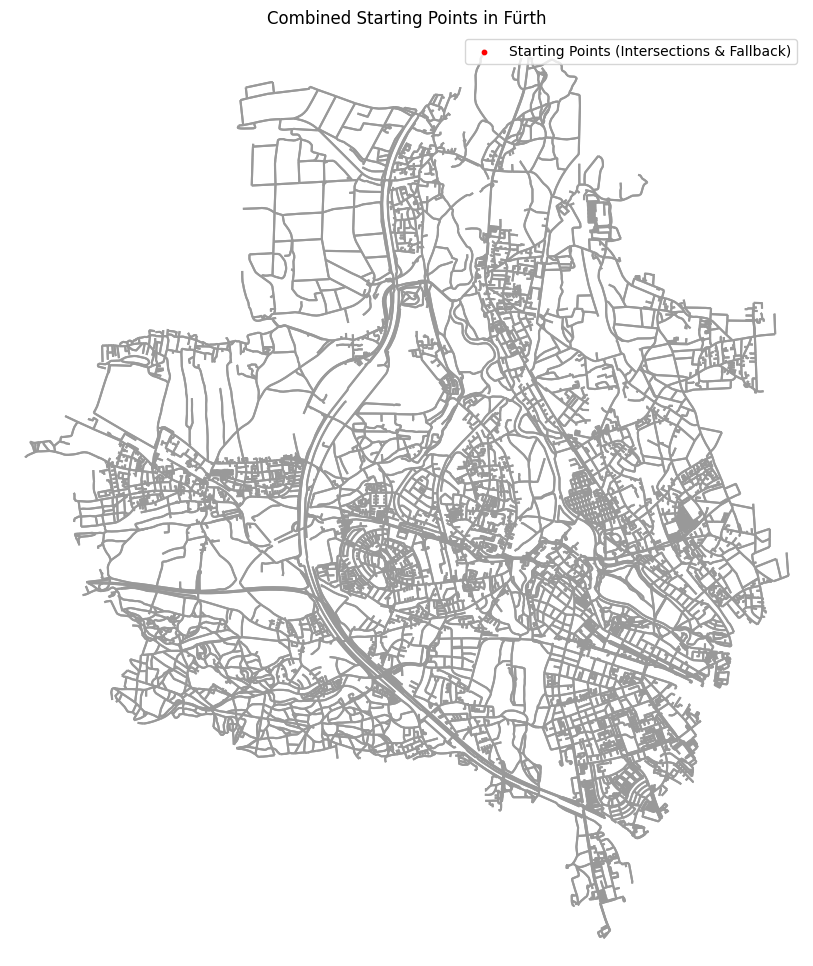

  Finished plotting for Fürth

Plotting combined starting points for Bamberg...
  Accessed projected street network graph for Bamberg
  Accessed cold spot boundaries for Bamberg using key: Bamberg 2019 2024 cold spots combined 2019 2024.gpkg
  Reprojecting cold spot boundaries for Bamberg to match starting points CRS
  Finished reprojecting cold spot boundaries for Bamberg


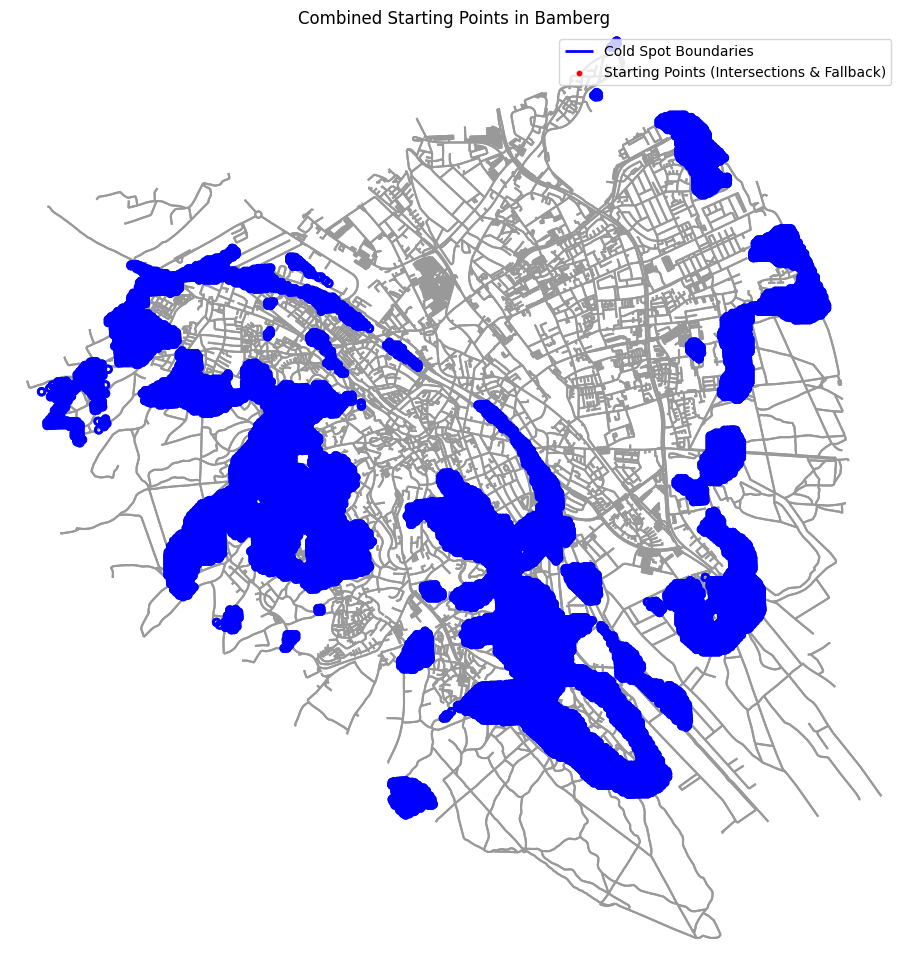

  Finished plotting for Bamberg

Plotting combined starting points for Augsburg...
  Accessed projected street network graph for Augsburg
  Accessed cold spot boundaries for Augsburg using key: Augsburg 2019 2024 cold spots combined 2019 2024.gpkg
  Reprojecting cold spot boundaries for Augsburg to match starting points CRS
  Finished reprojecting cold spot boundaries for Augsburg


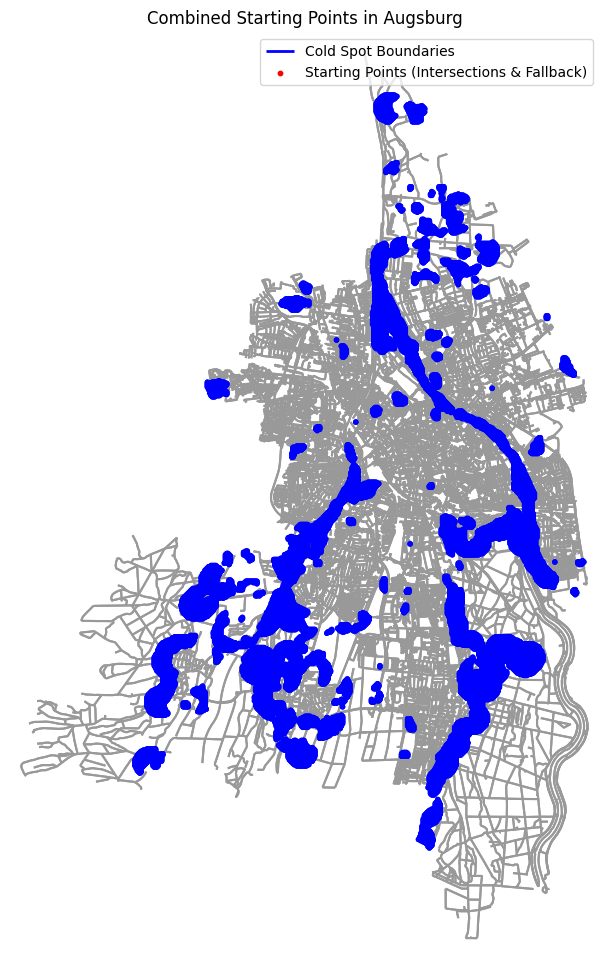

  Finished plotting for Augsburg

Plotting combined starting points for Munich...
  Accessed projected street network graph for Munich
  Accessed cold spot boundaries for Munich using key: Munich 2019 2024 cold spots combined 2019 2024.gpkg
  Reprojecting cold spot boundaries for Munich to match starting points CRS
  Finished reprojecting cold spot boundaries for Munich


KeyboardInterrupt: 

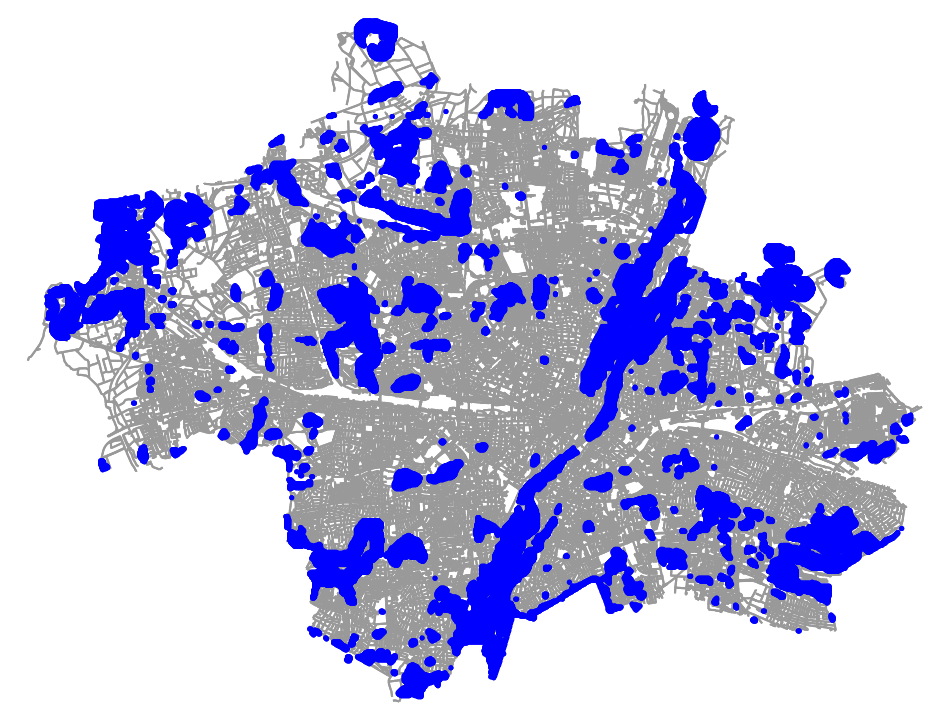

In [ ]:
import osmnx as ox
import matplotlib.pyplot as plt

# Create a mapping from the keys in all_starting_points_2019_2024 to the keys in graphs_proj
starting_points_to_graphs_mapping = {}
for sp_key in all_starting_points_2019_2024.keys():
    # Extract city name from the starting_points_2019_2024 key (e.g., "Aschaffenburg_starting_points_2019_2024" -> "Aschaffenburg")
    # Handle potential variations in naming (e.g., umlauts, spaces)
    cleaned_city_name = sp_key.replace("_starting_points_2019_2024", "").replace("_", " ")

    # Further refine cleaning to match graphs_proj keys if necessary
    if "Aschaffenburg" in cleaned_city_name:
        graphs_proj_key = "Aschaffenburg"
    elif "Augsburg" in cleaned_city_name:
        graphs_proj_key = "Augsburg"
    elif "Bamberg" in cleaned_city_name:
        graphs_proj_key = "Bamberg"
    elif "Bayreuth" in cleaned_city_name:
        graphs_proj_key = "Bayreuth"
    elif "Erlangen" in cleaned_city_name:
        graphs_proj_key = "Erlangen"
    elif "Fuerth" in cleaned_city_name: # Match the key used in graphs_proj
        graphs_proj_key = "Fürth"
    elif "Ingolstadt" in cleaned_city_name:
        graphs_proj_key = "Ingolstadt"
    elif "Kempten Allgaeu" in cleaned_city_name: # Match the key used in graphs_proj
        graphs_proj_key = "Kempten (Allgäu)"
    elif "Landshut" in cleaned_city_name:
        graphs_proj_key = "Landshut"
    elif "Munich" in cleaned_city_name:
        graphs_proj_key = "Munich"
    elif "Nuremberg" in cleaned_city_name:
        graphs_proj_key = "Nuremberg"
    elif "Passau" in cleaned_city_name:
        graphs_proj_key = "Passau"
    elif "Regensburg" in cleaned_city_name:
        graphs_proj_key = "Regensburg"
    elif "Rosenheim" in cleaned_city_name:
        graphs_proj_key = "Rosenheim"
    elif "Schweinfurt" in cleaned_city_name:
        graphs_proj_key = "Schweinfurt"
    elif "Wuerzburg" in cleaned_city_name: # Match the key used in graphs_proj
        graphs_proj_key = "Würzburg"
    else:
        graphs_proj_key = cleaned_city_name # Default to cleaned name if no specific mapping

    starting_points_to_graphs_mapping[sp_key] = graphs_proj_key


# Create a mapping from city name (as key in all_starting_points_2019_2024)
# to the key used in the cold_spot_boundaries_2019_2024_p001 dictionary (the full filename)
cold_spot_boundary_key_mapping_2019_2024 = {}
if 'cold_spot_boundaries_2019_2024_p001' in locals():
    for key in cold_spot_boundaries_2019_2024_p001.keys():
        # Extract city name from the filename key (assuming format "CityName_cold_spots_combined_2019_2024.gpkg")
        city_name_from_key = key.replace("_cold_spots_combined_2019_2024.gpkg", "").replace("_", " ")
        # Handle specific city name variations if necessary to match keys in all_starting_points_2019_2024
        if "Aschaffenburg" in key:
             city_name_from_key = "Aschaffenburg"
        elif "Augsburg" in key:
             city_name_from_key = "Augsburg"
        elif "Bamberg" in key:
             city_name_from_key = "Bamberg"
        elif "Bayreuth" in key:
             city_name_from_key = "Bayreuth"
        elif "Erlangen" in key:
             city_name_from_key = "Erlangen"
        elif "Fürth" in key: # Handle the umlaut as it appears in the filename
             city_name_from_key = "Fürth" # Map to the key used in all_starting_points_2019_2024
        elif "Ingolstadt" in key:
             city_name_from_key = "Ingolstadt"
        elif "Kempten (Allgäu)" in key: # Handle the special characters as they appear in the filename
             city_name_from_key = "Kempten (Allgäu)" # Map to the key used in all_starting_points_2019_2024
        elif "Landshut" in key:
             city_name_from_key = "Landshut"
        elif "Munich" in key:
             city_name_from_key = "Munich"
        elif "Nuremberg" in key:
             city_name_from_key = "Nuremberg"
        elif "Passau" in key:
             city_name_from_key = "Passau"
        elif "Regensburg" in key:
             city_name_from_key = "Regensburg"
        elif "Rosenheim" in key:
             city_name_from_key = "Rosenheim"
        elif "Schweinfurt" in key:
             city_name_from_key = "Schweinfurt"
        elif "Würzburg" in key: # Handle the umlaut as it appears in the filename
             city_name_from_key = "Würzburg" # Map to the key used in all_starting_points_2019_2024
        # Add any other necessary mappings here based on your filenames and all_starting_points_2019_2024 keys

        # Ensure the key in the mapping matches the cleaned city name used for graph lookup
        cold_spot_boundary_key_mapping_2019_2024[city_name_from_key] = key


# Iterate through the combined starting points for each city
for starting_points_key, starting_points_gdf in all_starting_points_2019_2024.items():
    # Get the corresponding graph_proj key for the current starting_points_key
    city_name = starting_points_to_graphs_mapping.get(starting_points_key)

    if city_name: # Proceed only if a valid city name was found
        print(f"\nPlotting combined starting points for {city_name}...")

        # Access the street network graph for the current city
        if city_name in graphs_proj: # Use the projected graph
            graph_proj = graphs_proj[city_name]
            print(f"  Accessed projected street network graph for {city_name}")

            # Access the cold spot boundaries for the current city using the mapping
            cold_spot_boundary_key = cold_spot_boundary_key_mapping_2019_2024.get(city_name)

            if cold_spot_boundary_key and cold_spot_boundary_key in cold_spot_boundaries_2019_2024_p001:
                 cold_spot_boundaries_gdf = cold_spot_boundaries_2019_2024_p001[cold_spot_boundary_key]
                 print(f"  Accessed cold spot boundaries for {city_name} using key: {cold_spot_boundary_key}")
            else:
                 cold_spot_boundaries_gdf = gpd.GeoDataFrame(geometry=[], crs='epsg:32632') # Create empty if not found
                 print(f"  Cold spot boundaries not found for {city_name} using mapping. Plotting without boundaries.")


            # Ensure cold spot boundaries have the correct CRS before plotting
            if cold_spot_boundaries_gdf.crs != starting_points_gdf.crs:
                if not cold_spot_boundaries_gdf.empty:
                    print(f"  Reprojecting cold spot boundaries for {city_name} to match starting points CRS")
                    cold_spot_boundaries_gdf_proj = cold_spot_boundaries_gdf.to_crs(starting_points_gdf.crs)
                    print(f"  Finished reprojecting cold spot boundaries for {city_name}")
                else:
                    cold_spot_boundaries_gdf_proj = cold_spot_boundaries_gdf # Keep empty gdf
                    print(f"  Empty cold spot boundaries for {city_name}. No reprojecting needed.")
            else:
                cold_spot_boundaries_gdf_proj = cold_spot_boundaries_gdf
                print(f"  CRS of cold spot boundaries matches starting points for {city_name}")


            # --- Plotting ---
            fig, ax = plt.subplots(figsize=(12, 12))

            # Plot the street network
            # Use the already projected graph_proj
            ox.plot_graph(graph_proj, ax=ax, node_size=0, edge_color='#999999', edge_linewidth=1.5, show=False, close=False)

            # Plot the cold spot boundaries if available
            if not cold_spot_boundaries_gdf_proj.empty:
                cold_spot_boundaries_gdf_proj.plot(ax=ax, color='blue', linewidth=2, label='Cold Spot Boundaries')

            # Plot the combined starting points
            starting_points_gdf.plot(ax=ax, color='red', markersize=10, label='Starting Points (Intersections & Fallback)')

            ax.set_title(f"Combined Starting Points in {city_name}")
            ax.legend()
            plt.show()
            print(f"  Finished plotting for {city_name}")

        else:
            print(f"  Projected street network graph not found for {city_name} in graphs_proj. Skipping plotting.")
    else:
        print(f"  Could not map starting points key '{starting_points_key}' to a city name in graphs_proj. Skipping plotting.")


print("\nFinished plotting combined starting points for all cities.")

# Erreichbarkeitsanalyse

ausgehend von diesen Schnittpunkten (Intersections und Fallbacks) jetzt Erreichbarkeitsanalyse entlang der edges (Straßen) => gibt Straßenabschnitte aus die bei 1m/s Geschwindigkeit innerhalb von 5, 10, 15, 20 und 25 Minuten zu Fuß erreichbar sind => Straßenabschnitte sollen dann umgewandelt werden in Geometrien => konvexe Hülle, aber gruppiert nachder group_id der Cold Spots, sodass jeder Cold Spot eigene Erreichbarkeitshüllen bekommt

Calculate and visualize accessibility polygons (convex hulls) for Cold Spot groups in several Bavarian cities based on walking travel times (5, 10, 15, 20, 25 minutes) from the combined intersection and fallback points, using the previously loaded OSMnx street network graphs. Group the accessibility polygons by the original Cold Spot group_id.

## Geschwindigkeit und Reisezeiten definieren



In [23]:
# Define walking speed in meters per second
travel_speed = 1 # m/s

# Define travel times in minutes
travel_times_minutes = [5, 10, 15, 20, 25, 30]

print(f"Walking speed: {travel_speed} m/s")
print(f"Travel times in minutes: {travel_times_minutes}")

Walking speed: 1 m/s
Travel times in minutes: [5, 10, 15, 20, 25, 30]


## Reisezeit für jeden Straßenabschnitt(edge) im Graphen berechnen

In [24]:
import networkx as nx

# Iterate through the graphs dictionary
for city_name, G in graphs_proj.items():
    print(f"Calculating travel times for edges in {city_name} graph...")

    # Calculate travel time for each edge
    # Ensure the graph has the 'length' attribute for edges
    if all('length' in G.edges[u, v, k] for u, v, k in G.edges):
        # Add 'travel_time' attribute (in seconds) to each edge
        for u, v, k, data in G.edges(keys=True, data=True):
            data['travel_time'] = data['length'] / travel_speed
        print(f"  Added 'travel_time' attribute to edges in {city_name} graph.")
    else:
        print(f"  Warning: 'length' attribute not found on all edges in {city_name} graph. Skipping travel time calculation for this graph.")

print("\nFinished calculating travel times for edges in all graphs.")

# You can inspect the edges of a graph to see the new attribute
# For example: list(graphs['Nuremberg'].edges(data=True))[0]

Calculating travel times for edges in Aschaffenburg graph...
  Added 'travel_time' attribute to edges in Aschaffenburg graph.
Calculating travel times for edges in Augsburg graph...
  Added 'travel_time' attribute to edges in Augsburg graph.
Calculating travel times for edges in Bamberg graph...
  Added 'travel_time' attribute to edges in Bamberg graph.
Calculating travel times for edges in Bayreuth graph...
  Added 'travel_time' attribute to edges in Bayreuth graph.
Calculating travel times for edges in Erlangen graph...
  Added 'travel_time' attribute to edges in Erlangen graph.
Calculating travel times for edges in Fürth graph...
  Added 'travel_time' attribute to edges in Fürth graph.
Calculating travel times for edges in Ingolstadt graph...
  Added 'travel_time' attribute to edges in Ingolstadt graph.
Calculating travel times for edges in Kempten (Allgäu) graph...
  Added 'travel_time' attribute to edges in Kempten (Allgäu) graph.
Calculating travel times for edges in Landshut

# Service Area Analyse

In [ ]:
import networkx as nx
import os
import geopandas as gpd

# Dictionary to store reachable nodes and edges for each city, group_id, and travel time
reachable_areas_all_cities = {}

# Convert travel times from minutes to seconds
travel_times_seconds = [t * 60 for t in travel_times_minutes]

# Define the output directory for reachable edges in Google Drive
output_base_dir = "/content/drive/MyDrive/Cold Spots Bayern"
output_dir_reachable_edges = os.path.join(output_base_dir, "reachable_edges_2019_2024_Puffer")

# Create the output directory if it doesn't exist
os.makedirs(output_dir_reachable_edges, exist_ok=True)
print(f"Saving reachable edges to: {output_dir_reachable_edges}")

# Create a mapping from the cleaned city names (used in graphs_proj)
# to the keys in all_starting_points_2019_2024 (the original filenames)
starting_points_key_mapping = {}
if 'all_starting_points_2019_2024' in locals():
    for key in all_starting_points_2019_2024.keys():
        # Extract city name from the starting_points_2019_2024 key (e.g., "Aschaffenburg_starting_points_2019_2024" -> "Aschaffenburg")
        # Handle potential variations in naming (e.g., umlauts, spaces) to match graphs_proj keys
        cleaned_city_name = key.replace("_starting_points_2019_2024", "").replace("_", " ")
        # Further refine cleaning to match graphs_proj keys if necessary
        cleaned_city_name = cleaned_city_name.replace("Fuerth", "Fürth").replace("Wuerzburg", "Würzburg").replace("Kempten Allgaeu", "Kempten (Allgäu)")
        starting_points_key_mapping[cleaned_city_name] = key


# Iterate through the keys of graphs_proj, as this is the dictionary
# with the correct city names for accessing the graphs.
for city_name in graphs_proj.keys():

    print(f"\nCalculating reachable nodes and edges for city: {city_name}")

    # Initialize dictionary for the current city
    reachable_areas_all_cities[city_name] = {}

    # Access the street network graph for the current city
    # The graph is already projected and has travel times calculated
    G = graphs_proj[city_name]

    # Find the corresponding starting points GeoDataFrame for the current city using the mapping.
    if city_name in starting_points_key_mapping:
        starting_points_key = starting_points_key_mapping[city_name]
        if starting_points_key in all_starting_points_2019_2024 and not all_starting_points_2019_2024[starting_points_key].empty:
            starting_point_gdf = all_starting_points_2019_2024[starting_points_key]
            print(f"  Accessed starting points GeoDataFrame for {city_name} using key: {starting_points_key}")

             # Project the starting points to the graph's CRS if they are different
            if starting_point_gdf.crs != G.graph['crs']:
                print(f"  Projecting starting points for {city_name} to graph CRS: {G.graph['crs']}")
                starting_point_gdf = starting_point_gdf.to_crs(G.graph['crs'])
                print(f"  Finished projecting starting points for {city_name}")
            else:
                print(f"  CRS of starting points matches graph CRS for {city_name}: {G.graph['crs']}")


            # Iterate through each starting point in the city's GeoDataFrame
            print(f"  Processing {len(starting_point_gdf)} starting points for {city_name}...")
            for index, starting_point in starting_point_gdf.iterrows():
                # Get the group_id for this starting point
                group_id = starting_point.get('group_id', 'unknown_group') # Use .get() with a default for safety

                # Initialize dictionary for the current group_id within the city if it doesn't exist
                if group_id not in reachable_areas_all_cities[city_name]:
                     reachable_areas_all_cities[city_name][group_id] = {}

                # Initialize another nested dictionary for the current starting point's index
                if index not in reachable_areas_all_cities[city_name][group_id]:
                    reachable_areas_all_cities[city_name][group_id][index] = {}

                # Find the nearest node in the projected graph to the starting point's geometry
                try:
                    nearest_node_osmid = ox.nearest_nodes(G, starting_point.geometry.x, starting_point.geometry.y)
                except Exception as e:
                    print(f"      Could not find nearest node for starting point index {index} (group_id: {group_id}): {e}. Skipping this point.")
                    continue

                # For each travel time:
                for travel_time_sec, travel_time_min in zip(travel_times_seconds, travel_times_minutes):
                    # print(f"      Calculating reachable nodes for {travel_time_min} minutes for starting point index {index}, group_id {group_id}...") # Removed detailed print
                    try:
                        distances, _ = nx.single_source_dijkstra(G, source=nearest_node_osmid, cutoff=travel_time_sec, weight='travel_time')
                        reachable_nodes_osmid = set(distances.keys())

                        edges_proj_list = list(G.edges(keys=True, data=True))
                        reachable_edges = []
                        for u, v, k, data in edges_proj_list:
                             if u in reachable_nodes_osmid and v in reachable_nodes_osmid:
                                  reachable_edges.append((u, v, k, data))


                        reachable_areas_all_cities[city_name][group_id][index][travel_time_min] = {
                            'reachable_nodes_osmid': reachable_nodes_osmid,
                            'reachable_edges': reachable_edges
                        }
                    except Exception as e:
                        print(f"      Could not calculate reachable nodes/edges for {travel_time_min} minutes for starting point index {index}, group_id {group_id}: {e}. Skipping this travel time for this point.")
                        reachable_areas_all_cities[city_name][group_id][index][travel_time_min] = {
                            'reachable_nodes_osmid': set(),
                            'reachable_edges': []
                        }

            # After processing all starting points for a city, save the reachable edges data
            print(f"\nSaving reachable edges for {city_name}...")
            city_reachable_edges_data = reachable_areas_all_cities[city_name]

            # Prepare data for saving: flatten the structure for easier GeoDataFrame creation
            # Each row in the output GeoDataFrame will represent a reachable edge with its associated
            # city, group_id, starting_point_index, travel_time_min, and geometry.
            edges_to_save = []
            for group_id, group_data in city_reachable_edges_data.items():
                for starting_point_index, travel_time_data in group_data.items():
                    for travel_time_min, reachable_data in travel_time_data.items():
                        for u, v, k, data in reachable_data['reachable_edges']:
                            if 'geometry' in data:
                                edges_to_save.append({
                                    'city': city_name,
                                    'group_id': group_id,
                                    'start_pt_idx': starting_point_index, # Include starting point index for traceability
                                    'travel_time': travel_time_min,
                                    'osmid_u': u, # Include OSM IDs of the edge nodes
                                    'osmid_v': v,
                                    'osmid_k': k, # Include key for MultiDiGraph
                                    'geometry': data['geometry']
                                })

            if edges_to_save:
                # Create a GeoDataFrame from the collected edge data
                # Use the same CRS as the projected graph
                reachable_edges_gdf = gpd.GeoDataFrame(edges_to_save, crs=G.graph['crs'])

                # Create a safe filename for the city
                safe_city_name = city_name.replace(" ", "_").replace("(", "").replace(")", "").replace("̈", "e").replace("ä", "ae").replace("ö", "oe").replace("ü", "ue")
                output_filepath = os.path.join(output_dir_reachable_edges, f"{safe_city_name}_reachable_edges.gpkg")

                try:
                    # Save the GeoDataFrame to a GeoPackage file
                    reachable_edges_gdf.to_file(output_filepath, driver='GPKG')
                    print(f"  Successfully saved reachable edges for {city_name} to {output_filepath}")
                except Exception as e:
                    print(f"  Error saving reachable edges for {city_name} to {output_filepath}: {e}")
            else:
                print(f"  No reachable edges found for {city_name} to save.")


        else:
            print(f"  Starting points GeoDataFrame not found or is empty for {city_name} using key {starting_points_key}. Skipping reachable area calculation for this city.")

    else:
         print(f"  Starting points key not found for {city_name} in the mapping. Skipping reachable area calculation for this city.")


print("\nFinished calculating and saving reachable nodes and edges for all cities.")

Saving reachable edges to: /content/drive/MyDrive/Cold Spots Bayern/reachable_edges_2019_2024_Puffer

Calculating reachable nodes and edges for city: Aschaffenburg
  Accessed starting points GeoDataFrame for Aschaffenburg using key: Aschaffenburg
  CRS of starting points matches graph CRS for Aschaffenburg: epsg:32632
  Processing 68603 starting points for Aschaffenburg...


## Erreichbare Straßenabschnitte nach group_id gruppieren

für jede travel time die erreichbaren Straßenabschnitte für jeden Cold Spot  kombinieren

In [ ]:
import geopandas as gpd
from shapely.geometry import LineString

# Dictionary to store reachable edge geometries grouped by group_id and travel time for all cities (except Nuremberg)
grouped_reachable_edges_geom_all_cities = {}

# Iterate through each city in the reachable_areas_all_cities dictionary
for city_name, city_reachable_areas in reachable_areas_all_cities.items():
    print(f"\nGrouping reachable edges by group_id for {city_name}...")

    # Initialize dictionary for the current city in the grouped results
    grouped_reachable_edges_geom_all_cities[city_name] = {}

    # Iterate through each group_id in the city's reachable areas
    for group_id, group_data in city_reachable_areas.items():
        # print(f"  Processing group_id: {group_id}") # Optional debug print

        # Initialize dictionary for the current group_id within the city
        grouped_reachable_edges_geom_all_cities[city_name][group_id] = {}

        # Iterate through each starting point index within the group_id
        for starting_point_index, travel_time_data in group_data.items():
             # Iterate through each travel time for the starting point
             for travel_time_min, reachable_data in travel_time_data.items():
                 # print(f"    Processing {travel_time_min} minutes for starting point index {starting_point_index}...") # Optional debug print

                 reachable_edges = reachable_data['reachable_edges']

                 # If this is the first time encountering this travel time for this group_id, initialize the list
                 if travel_time_min not in grouped_reachable_edges_geom_all_cities[city_name][group_id]:
                      grouped_reachable_edges_geom_all_cities[city_name][group_id][travel_time_min] = []

                 # Append the geometries of the reachable edges
                 # Each item in reachable_edges is a tuple (u, v, k, data)
                 for u, v, k, data in reachable_edges:
                      if 'geometry' in data:
                           grouped_reachable_edges_geom_all_cities[city_name][group_id][travel_time_min].append(data['geometry'])
                      else:
                           # If geometry is not directly available, handle as needed (e.g., reconstruct from node geometries)
                           pass


    print(f"Finished grouping reachable edge geometries by group_id and travel time for {city_name}.")

print("\nFinished grouping reachable edge geometries for all cities (excluding Nuremberg).")

# The 'grouped_reachable_edges_geom_all_cities' dictionary now contains reachable edge geometries,
# structured as: grouped_reachable_edges_geom_all_cities[city_name][group_id][travel_time_min] = [list of geometries]


Grouping reachable edges by group_id for Aschaffenburg...
Finished grouping reachable edge geometries by group_id and travel time for Aschaffenburg.

Grouping reachable edges by group_id for Augsburg...
Finished grouping reachable edge geometries by group_id and travel time for Augsburg.

Grouping reachable edges by group_id for Bayreuth...
Finished grouping reachable edge geometries by group_id and travel time for Bayreuth.

Grouping reachable edges by group_id for Erlangen...
Finished grouping reachable edge geometries by group_id and travel time for Erlangen.

Grouping reachable edges by group_id for Fürth...
Finished grouping reachable edge geometries by group_id and travel time for Fürth.

Grouping reachable edges by group_id for Ingolstadt...
Finished grouping reachable edge geometries by group_id and travel time for Ingolstadt.

Grouping reachable edges by group_id for Landshut...
Finished grouping reachable edge geometries by group_id and travel time for Landshut.

Grouping 

## erreichbare edges in GeoDataframes speichern

In [ ]:
import geopandas as gpd
from shapely.geometry import LineString

# Dictionary to store reachable edges as GeoDataFrames grouped by city, group_id, and travel time
reachable_edges_gdf_all_cities = {}

# Iterate through each city and its grouped reachable edge geometries
for city_name, grouped_data in grouped_reachable_edges_geom_all_cities.items():
    print(f"\nConverting reachable edge geometries to GeoDataFrames for {city_name}...")

    # Initialize dictionary for the current city
    reachable_edges_gdf_all_cities[city_name] = {}

    # Iterate through each group_id and its data
    for group_id, travel_time_data in grouped_data.items():
        # print(f"  Processing group_id: {group_id}") # Optional debug print

        # Initialize dictionary for the current group_id
        reachable_edges_gdf_all_cities[city_name][group_id] = {}

        # Iterate through each travel time and its list of geometries
        for travel_time_min, geometries_list in travel_time_data.items():
            # print(f"    Converting geometries for {travel_time_min} minutes...") # Optional debug print

            if geometries_list:
                # Create a GeoDataFrame from the list of geometries
                # Use EPSG:32632 as the CRS, consistent with previous steps
                gdf = gpd.GeoDataFrame(geometry=geometries_list, crs='epsg:32632')
                reachable_edges_gdf_all_cities[city_name][group_id][travel_time_min] = gdf
                # print(f"      Created GeoDataFrame with {len(gdf)} edges for {travel_time_min} minutes.") # Optional debug print
            else:
                # Create an empty GeoDataFrame if there are no geometries
                reachable_edges_gdf_all_cities[city_name][group_id][travel_time_min] = gpd.GeoDataFrame(geometry=[], crs='epsg:32632')
                # print(f"      No geometries found for {travel_time_min} minutes. Created empty GeoDataFrame.") # Optional debug print


    print(f"Finished converting reachable edge geometries to GeoDataFrames for {city_name}.")

print("\nFinished converting reachable edge geometries to GeoDataFrames for all cities (excluding Nuremberg).")

# The 'reachable_edges_gdf_all_cities' dictionary now contains GeoDataFrames of reachable edges,
# structured as: reachable_edges_gdf_all_cities[city_name][group_id][travel_time_min] = GeoDataFrame


Converting reachable edge geometries to GeoDataFrames for Aschaffenburg...
Finished converting reachable edge geometries to GeoDataFrames for Aschaffenburg.

Converting reachable edge geometries to GeoDataFrames for Augsburg...
Finished converting reachable edge geometries to GeoDataFrames for Augsburg.

Converting reachable edge geometries to GeoDataFrames for Bayreuth...
Finished converting reachable edge geometries to GeoDataFrames for Bayreuth.

Converting reachable edge geometries to GeoDataFrames for Erlangen...
Finished converting reachable edge geometries to GeoDataFrames for Erlangen.

Converting reachable edge geometries to GeoDataFrames for Fürth...
Finished converting reachable edge geometries to GeoDataFrames for Fürth.

Converting reachable edge geometries to GeoDataFrames for Ingolstadt...
Finished converting reachable edge geometries to GeoDataFrames for Ingolstadt.

Converting reachable edge geometries to GeoDataFrames for Landshut...
Finished converting reachable e

## konvexe Hüllen erzeugen für jede travel time


In [ ]:
import geopandas as gpd
from shapely.geometry import Polygon, MultiPolygon

# Dictionary to store the convex hull polygons grouped by city, group_id, and travel time
accessibility_polygons_all_cities = {}

# Iterate through each city and its reachable edges GeoDataFrame data
for city_name, city_data in reachable_edges_gdf_all_cities.items():
    print(f"\nCreating convex hulls for {city_name}...")

    # Initialize dictionary for the current city
    accessibility_polygons_all_cities[city_name] = {}

    # Iterate through each group_id and its data in the city's reachable edges GeoDataFrame data
    for group_id, travel_time_data in city_data.items():
        # print(f"  Processing group_id: {group_id}") # Optional debug print

        # Initialize dictionary for the current group_id
        accessibility_polygons_all_cities[city_name][group_id] = {}

        # Iterate through each travel time and its GeoDataFrame for the group_id
        for travel_time_min, edges_gdf in travel_time_data.items():
             # print(f"    Creating convex hull for {travel_time_min} minutes...") # Optional debug print

             if not edges_gdf.empty:
                  try:
                      # Calculate the convex hull of all geometries in the GeoDataFrame
                      # .unary_union combines all geometries into a single geometry collection
                      # .convex_hull calculates the convex hull of this collection
                      convex_hull_geom = edges_gdf.geometry.union_all().convex_hull

                      # Store the resulting polygon
                      # Create a GeoDataFrame for the single convex hull polygon
                      # Ensure the CRS is set correctly (should be the same as the input edges_gdf)
                      accessibility_polygons_all_cities[city_name][group_id][travel_time_min] = gpd.GeoDataFrame(geometry=[convex_hull_geom], crs=edges_gdf.crs)
                      # print(f"        Created convex hull polygon for {travel_time_min} minutes.") # Optional debug print
                  except Exception as e:
                      print(f"      Could not create convex hull for {travel_time_min} minutes for group_id {group_id} in {city_name}: {e}. Creating empty GeoDataFrame.")
                      # Create an empty GeoDataFrame in case of an error during convex hull creation
                      accessibility_polygons_all_cities[city_name][group_id][travel_time_min] = gpd.GeoDataFrame(geometry=[], crs='epsg:32632') # Use expected CRS
             else:
                  # Create an empty GeoDataFrame if there are no edges
                  accessibility_polygons_all_cities[city_name][group_id][travel_time_min] = gpd.GeoDataFrame(geometry=[], crs='epsg:32632') # Use expected CRS
                  # print(f"        No edges found for {travel_time_min} minutes. Created empty GeoDataFrame for convex hull.") # Optional debug print

    print(f"Finished creating convex hulls for {city_name}.")

print("\nFinished creating convex hulls for all cities (excluding Nuremberg).")

# The 'accessibility_polygons_all_cities' dictionary now contains GeoDataFrames of convex hull polygons,
# structured as: accessibility_polygons_all_cities[city_name][group_id][travel_time_min] = GeoDataFrame (with one polygon)


Creating convex hulls for Aschaffenburg...
Finished creating convex hulls for Aschaffenburg.

Creating convex hulls for Augsburg...
Finished creating convex hulls for Augsburg.

Creating convex hulls for Bayreuth...
Finished creating convex hulls for Bayreuth.

Creating convex hulls for Erlangen...
Finished creating convex hulls for Erlangen.

Creating convex hulls for Fürth...
Finished creating convex hulls for Fürth.

Creating convex hulls for Ingolstadt...
Finished creating convex hulls for Ingolstadt.

Creating convex hulls for Landshut...
Finished creating convex hulls for Landshut.

Creating convex hulls for Passau...
Finished creating convex hulls for Passau.

Creating convex hulls for Regensburg...
Finished creating convex hulls for Regensburg.

Creating convex hulls for Rosenheim...
Finished creating convex hulls for Rosenheim.

Creating convex hulls for Schweinfurt...
Finished creating convex hulls for Schweinfurt.

Creating convex hulls for Würzburg...
Finished creating 

## Erreichbarkeitspolygone speichern


In [ ]:
# The accessibility polygons for all cities (except Nuremberg) are stored in the 'accessibility_polygons_all_cities' dictionary.
# You can inspect its keys and structure to confirm the results.

print("Accessibility polygons for all cities (excluding Nuremberg) have been generated and stored in 'accessibility_polygons_all_cities'.")
print(f"Cities processed: {list(accessibility_polygons_all_cities.keys())}")

# You can access the polygons for a specific city, group_id, and travel time like this:
# city_to_inspect = list(accessibility_polygons_all_cities.keys())[0] # Example: get the first city
# if city_to_inspect in accessibility_polygons_all_cities and accessibility_polygons_all_cities[city_to_inspect]:
#     group_id_to_inspect = list(accessibility_polygons_all_cities[city_to_inspect].keys())[0] # Example: get the first group_id for the city
#     if group_id_to_inspect in accessibility_polygons_all_cities[city_to_inspect] and accessibility_polygons_all_cities[city_to_inspect][group_id_to_inspect]:
#         travel_time_to_inspect = list(accessibility_polygons_all_cities[city_to_inspect][group_id_to_inspect].keys())[0] # Example: get the first travel time for the group
#         example_polygon_gdf = accessibility_polygons_all_cities[city_to_inspect][group_id_to_inspect][travel_time_to_inspect]
#         print(f"\nExample accessibility polygon GeoDataFrame for {city_to_inspect}, group_id {group_id_to_inspect} at {travel_time_to_inspect} minutes:")
#         display(example_polygon_gdf)
#     else:
#         print(f"\nNo group_ids found for {city_to_inspect} in accessibility_polygons_all_cities.")
# else:
#     print(f"\nNo data found for {city_to_inspect} in accessibility_polygons_all_cities.")

Accessibility polygons for all cities (excluding Nuremberg) have been generated and stored in 'accessibility_polygons_all_cities'.
Cities processed: ['Aschaffenburg', 'Augsburg', 'Bayreuth', 'Erlangen', 'Fürth', 'Ingolstadt', 'Landshut', 'Passau', 'Regensburg', 'Rosenheim', 'Schweinfurt', 'Würzburg']


## Überschneidungen der Polygone auflösen zu einem gemeinsamen (nur innerhalb der travel times)

In [ ]:
import geopandas as gpd

# Dictionary to store the dissolved accessibility polygons grouped by city and travel time
dissolved_accessibility_polygons_all_cities = {}

# Iterate through each city and its accessibility polygon data
for city_name, city_data in accessibility_polygons_all_cities.items():
    print(f"\nDissolving accessibility polygons for {city_name}...")

    # Initialize dictionary for the current city
    dissolved_accessibility_polygons_all_cities[city_name] = {}

    # We need to dissolve based on travel time across all group_ids for that city
    # First, collect all polygons for each travel time across all group_ids
    polygons_by_travel_time = {}
    for group_id, travel_time_data in city_data.items():
        for travel_time_min, polygon_gdf in travel_time_data.items():
            if travel_time_min not in polygons_by_travel_time:
                polygons_by_travel_time[travel_time_min] = []
            if not polygon_gdf.empty:
                polygons_by_travel_time[travel_time_min].append(polygon_gdf)

    # Now, dissolve the collected polygons for each travel time
    for travel_time_min, gdf_list in polygons_by_travel_time.items():
        print(f"  Dissolving polygons for {travel_time_min} minutes in {city_name}...")
        if gdf_list:
            # Concatenate all GeoDataFrames for this travel time into a single GeoDataFrame
            combined_gdf = gpd.pd.concat(gdf_list, ignore_index=True)

            if not combined_gdf.empty:
                try:
                    # Dissolve the combined GeoDataFrame based on a dummy column or simply union all geometries
                    # Dissolving without a 'by' column unions all geometries into a single (Multi)Polygon
                    dissolved_polygon_gdf = combined_gdf.dissolve()

                    # Store the dissolved polygon GeoDataFrame
                    dissolved_accessibility_polygons_all_cities[city_name][travel_time_min] = dissolved_polygon_gdf
                    print(f"    Created dissolved polygon for {travel_time_min} minutes with {len(dissolved_polygon_gdf)} row(s).") # Should be 1 row if successful
                except Exception as e:
                    print(f"    Could not dissolve polygons for {travel_time_min} minutes in {city_name}: {e}. Creating empty GeoDataFrame.")
                    # Create an empty GeoDataFrame in case of an error during dissolution
                    dissolved_accessibility_polygons_all_cities[city_name][travel_time_min] = gpd.GeoDataFrame(geometry=[], crs='epsg:32632') # Use expected CRS

            else:
                 # If combined_gdf was empty, the dissolved result is also empty
                 dissolved_accessibility_polygons_all_cities[city_name][travel_time_min] = gpd.GeoDataFrame(geometry=[], crs='epsg:32632') # Use expected CRS
                 print(f"    No geometries to dissolve for {travel_time_min} minutes in {city_name}. Created empty GeoDataFrame.")

        else:
            # If gdf_list was empty, create an empty GeoDataFrame for this travel time
            dissolved_accessibility_polygons_all_cities[city_name][travel_time_min] = gpd.GeoDataFrame(geometry=[], crs='epsg:32632') # Use expected CRS
            print(f"    No data available for {travel_time_min} minutes in {city_name}. Created empty GeoDataFrame.")


    print(f"Finished dissolving polygons for {city_name}.")

print("\nFinished dissolving accessibility polygons for all cities (excluding Nuremberg).")

# The 'dissolved_accessibility_polygons_all_cities' dictionary now contains GeoDataFrames of dissolved polygons,
# structured as: dissolved_accessibility_polygons_all_cities[city_name][travel_time_min] = GeoDataFrame (with one polygon or multipolygon)


Dissolving accessibility polygons for Aschaffenburg...
  Dissolving polygons for 5 minutes in Aschaffenburg...
    Created dissolved polygon for 5 minutes with 1 row(s).
  Dissolving polygons for 10 minutes in Aschaffenburg...
    Created dissolved polygon for 10 minutes with 1 row(s).
  Dissolving polygons for 15 minutes in Aschaffenburg...
    Created dissolved polygon for 15 minutes with 1 row(s).
  Dissolving polygons for 20 minutes in Aschaffenburg...
    Created dissolved polygon for 20 minutes with 1 row(s).
  Dissolving polygons for 25 minutes in Aschaffenburg...
    Created dissolved polygon for 25 minutes with 1 row(s).
Finished dissolving polygons for Aschaffenburg.

Dissolving accessibility polygons for Augsburg...
  Dissolving polygons for 5 minutes in Augsburg...
    Created dissolved polygon for 5 minutes with 1 row(s).
  Dissolving polygons for 10 minutes in Augsburg...
    Created dissolved polygon for 10 minutes with 1 row(s).
  Dissolving polygons for 15 minutes in 

## Erreichbarkeitspolygone speichern (Shapefile oder GeoPackage?)

In [ ]:
import os
import geopandas as gpd

# Define the base output directory for the dissolved accessibility polygons shapefiles in Google Drive
output_dir_dissolved_polygons = "/content/drive/MyDrive/Cold Spots Bayern/Erreichbarkeiten_shapefiles_dissolved"
os.makedirs(output_dir_dissolved_polygons, exist_ok=True)

print(f"\nSaving dissolved accessibility polygons as shapefiles to: {output_dir_dissolved_polygons}")

# Iterate through the dissolved_accessibility_polygons_all_cities dictionary
for city_name, city_data in dissolved_accessibility_polygons_all_cities.items():
    print(f"Processing city for saving dissolved polygons: {city_name}")

    # Collect all dissolved polygons for the current city across all travel times
    all_travel_time_polygons = []
    for travel_time_min, dissolved_polygon_gdf in city_data.items():
        if not dissolved_polygon_gdf.empty:
            # Add a 'travel_time_min' column to identify the polygon
            dissolved_polygon_gdf['travel_time_min'] = travel_time_min
            all_travel_time_polygons.append(dissolved_polygon_gdf)

    # Concatenate all travel time polygons for the city into a single GeoDataFrame
    if all_travel_time_polygons:
        combined_city_gdf = gpd.pd.concat(all_travel_time_polygons, ignore_index=True)

        # Clean the city name for a valid filename
        cleaned_city_name = city_name.replace(" ", "_").replace("(", "").replace(")", "").replace("ä", "ae").replace("ö", "oe").replace("ü", "ue").replace("ß", "ss")

        # Define the output file path
        output_filepath = os.path.join(output_dir_dissolved_polygons, f"{cleaned_city_name}_dissolved_accessibility_polygons.shp")

        if not combined_city_gdf.empty:
            try:
                # Save the combined GeoDataFrame to a shapefile
                combined_city_gdf.to_file(output_filepath, driver='ESRI Shapefile')
                print(f"  Successfully saved dissolved polygons for {city_name} to {output_filepath}")
            except Exception as e:
                print(f"  Error saving dissolved polygons for {city_name} to {output_filepath}: {e}")
        else:
            print(f"  No dissolved polygons to save for {city_name}. Created an empty GeoDataFrame.")

    else:
        print(f"  No dissolved polygons found for any travel time for {city_name}. Skipping saving for this city.")


print("\nFinished saving dissolved accessibility polygons as shapefiles for all cities (excluding Nuremberg).")


Saving dissolved accessibility polygons as shapefiles to: /content/drive/MyDrive/Cold Spots Bayern/Erreichbarkeiten_shapefiles_dissolved
Processing city for saving dissolved polygons: Aschaffenburg
  Successfully saved dissolved polygons for Aschaffenburg to /content/drive/MyDrive/Cold Spots Bayern/Erreichbarkeiten_shapefiles_dissolved/Aschaffenburg_dissolved_accessibility_polygons.shp
Processing city for saving dissolved polygons: Augsburg
  Successfully saved dissolved polygons for Augsburg to /content/drive/MyDrive/Cold Spots Bayern/Erreichbarkeiten_shapefiles_dissolved/Augsburg_dissolved_accessibility_polygons.shp
Processing city for saving dissolved polygons: Bayreuth


/tmp/ipython-input-35-3376979619.py:35: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  combined_city_gdf.to_file(output_filepath, driver='ESRI Shapefile')
/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'travel_time_min' to 'travel_tim'
  ogr_write(
/tmp/ipython-input-35-3376979619.py:35: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  combined_city_gdf.to_file(output_filepath, driver='ESRI Shapefile')
/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'travel_time_min' to 'travel_tim'
  ogr_write(
/tmp/ipython-input-35-3376979619.py:35: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  combined_city_gdf.to_file(output_filepath, driver='ESRI Shapefile')
/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:723

  Successfully saved dissolved polygons for Bayreuth to /content/drive/MyDrive/Cold Spots Bayern/Erreichbarkeiten_shapefiles_dissolved/Bayreuth_dissolved_accessibility_polygons.shp
Processing city for saving dissolved polygons: Erlangen
  Successfully saved dissolved polygons for Erlangen to /content/drive/MyDrive/Cold Spots Bayern/Erreichbarkeiten_shapefiles_dissolved/Erlangen_dissolved_accessibility_polygons.shp
Processing city for saving dissolved polygons: Fürth
  Successfully saved dissolved polygons for Fürth to /content/drive/MyDrive/Cold Spots Bayern/Erreichbarkeiten_shapefiles_dissolved/Fürth_dissolved_accessibility_polygons.shp
Processing city for saving dissolved polygons: Ingolstadt
  Successfully saved dissolved polygons for Ingolstadt to /content/drive/MyDrive/Cold Spots Bayern/Erreichbarkeiten_shapefiles_dissolved/Ingolstadt_dissolved_accessibility_polygons.shp
Processing city for saving dissolved polygons: Landshut
  Successfully saved dissolved polygons for Landshut

/tmp/ipython-input-35-3376979619.py:35: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  combined_city_gdf.to_file(output_filepath, driver='ESRI Shapefile')
/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'travel_time_min' to 'travel_tim'
  ogr_write(
/tmp/ipython-input-35-3376979619.py:35: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  combined_city_gdf.to_file(output_filepath, driver='ESRI Shapefile')
/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'travel_time_min' to 'travel_tim'
  ogr_write(
/tmp/ipython-input-35-3376979619.py:35: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  combined_city_gdf.to_file(output_filepath, driver='ESRI Shapefile')
/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:723

  Successfully saved dissolved polygons for Passau to /content/drive/MyDrive/Cold Spots Bayern/Erreichbarkeiten_shapefiles_dissolved/Passau_dissolved_accessibility_polygons.shp
Processing city for saving dissolved polygons: Regensburg
  Successfully saved dissolved polygons for Regensburg to /content/drive/MyDrive/Cold Spots Bayern/Erreichbarkeiten_shapefiles_dissolved/Regensburg_dissolved_accessibility_polygons.shp
Processing city for saving dissolved polygons: Rosenheim
  Successfully saved dissolved polygons for Rosenheim to /content/drive/MyDrive/Cold Spots Bayern/Erreichbarkeiten_shapefiles_dissolved/Rosenheim_dissolved_accessibility_polygons.shp
Processing city for saving dissolved polygons: Schweinfurt
  Successfully saved dissolved polygons for Schweinfurt to /content/drive/MyDrive/Cold Spots Bayern/Erreichbarkeiten_shapefiles_dissolved/Schweinfurt_dissolved_accessibility_polygons.shp
Processing city for saving dissolved polygons: Würzburg
  Successfully saved dissolved polygo

/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'travel_time_min' to 'travel_tim'
  ogr_write(


## Visualisieren der Erreichbarkeiten


Visualizing dissolved accessibility polygons for selected cities (excluding Nuremberg): ['Aschaffenburg', 'Augsburg', 'Bayreuth']

Visualizing for city: Aschaffenburg
  Accessed street network graph for Aschaffenburg
  Accessed dissolved accessibility polygons data for Aschaffenburg
  Projecting graph for Aschaffenburg to EPSG:32632 for plotting
  Finished projecting graph for Aschaffenburg
  Travel times found for Aschaffenburg for plotting: [5, 10, 15, 20, 25]


/tmp/ipython-input-36-385757393.py:59: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/tmp/ipython-input-36-385757393.py:59: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


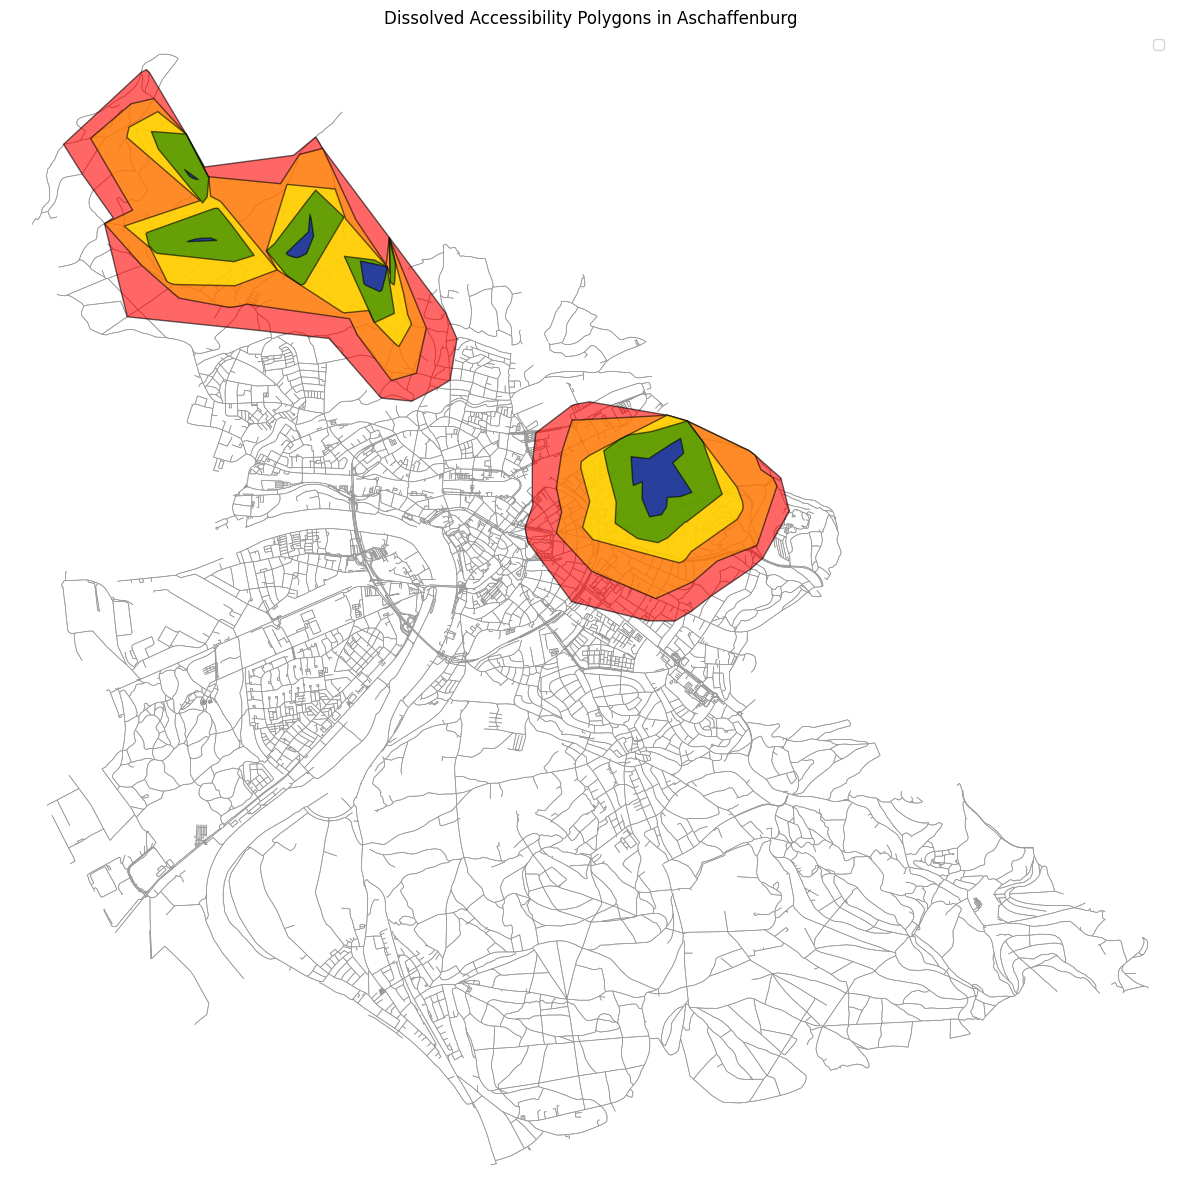

  Finished plotting for city: Aschaffenburg

Visualizing for city: Augsburg
  Accessed street network graph for Augsburg
  Accessed dissolved accessibility polygons data for Augsburg
  Projecting graph for Augsburg to EPSG:32632 for plotting
  Finished projecting graph for Augsburg
  Travel times found for Augsburg for plotting: [5, 10, 15, 20, 25]


/tmp/ipython-input-36-385757393.py:59: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/tmp/ipython-input-36-385757393.py:59: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


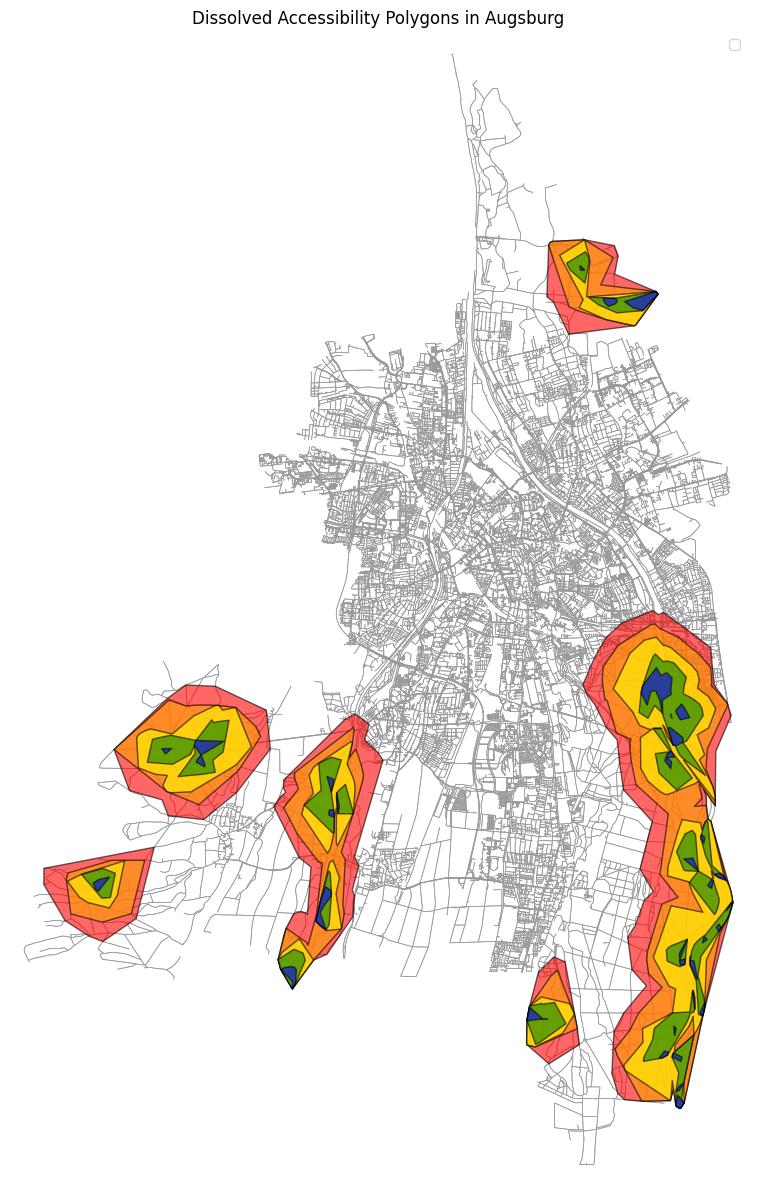

  Finished plotting for city: Augsburg

Visualizing for city: Bayreuth
  Accessed street network graph for Bayreuth
  Accessed dissolved accessibility polygons data for Bayreuth
  Projecting graph for Bayreuth to EPSG:32632 for plotting
  Finished projecting graph for Bayreuth
  Travel times found for Bayreuth for plotting: [5, 10, 15, 20, 25]


/tmp/ipython-input-36-385757393.py:59: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/tmp/ipython-input-36-385757393.py:59: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


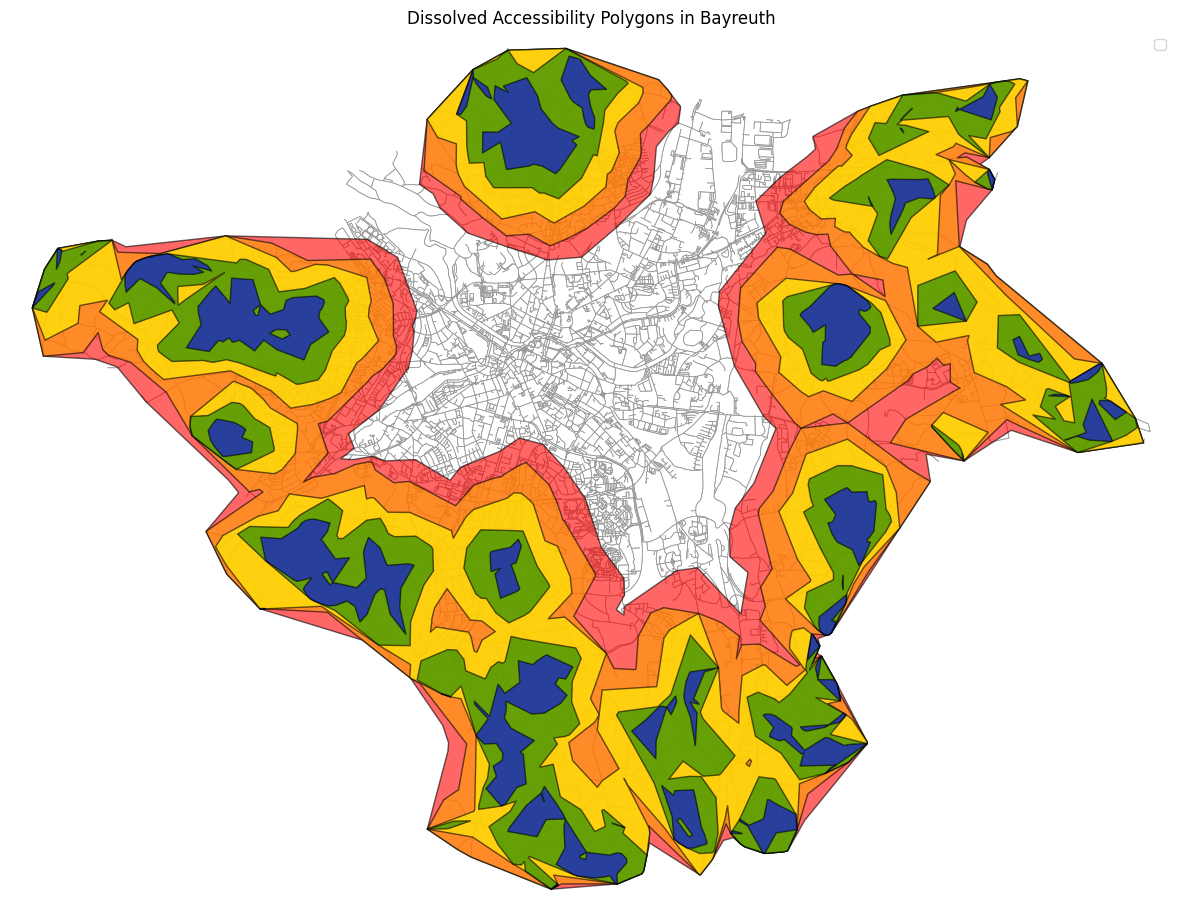

  Finished plotting for city: Bayreuth

Finished visualizing dissolved accessibility polygons for selected cities.


In [ ]:
import matplotlib.pyplot as plt
import osmnx as ox
import geopandas as gpd

# Define a list of cities to visualize (subset of processed cities, excluding Nuremberg)
cities_to_visualize = ['Aschaffenburg', 'Augsburg', 'Bayreuth','Erlangen', 'Fürth', 'Ingolstadt', 'Kempten (Allgäu)', 'Landshut', 'Passau', 'Regensburg', 'Rosennheim', 'Schweinfurt', 'Würzburg'] # You can change this list

print(f"\nVisualizing dissolved accessibility polygons for selected cities (excluding Nuremberg): {cities_to_visualize}")

# Iterate through the selected cities for visualization
for city_name in cities_to_visualize:
    if city_name in dissolved_accessibility_polygons_all_cities and dissolved_accessibility_polygons_all_cities[city_name]:
        print(f"\nVisualizing for city: {city_name}")

        # Access the street network graph for the current city
        if city_name in graphs:
            G = graphs[city_name]
            print(f"  Accessed street network graph for {city_name}")

            # Access the dissolved accessibility polygons for the current city
            city_dissolved_polygons = dissolved_accessibility_polygons_all_cities[city_name]
            print(f"  Accessed dissolved accessibility polygons data for {city_name}")

            # Project the graph to the same CRS as the accessibility polygons (EPSG:32632)
            if G.graph['crs'] != 'epsg:32632':
                print(f"  Projecting graph for {city_name} to EPSG:32632 for plotting")
                graph_proj = ox.project_graph(G, to_crs='epsg:32632')
                print(f"  Finished projecting graph for {city_name}")
            else:
                graph_proj = G
                print(f"  Graph for {city_name} is already in EPSG:32632")

            # --- Plotting ---
            # Create a single figure and axes for the current city
            fig, ax = plt.subplots(figsize=(15, 15))

            # Plot the street network
            ox.plot_graph(graph_proj, ax=ax, node_size=0, edge_color='#999999', edge_linewidth=0.5, show=False, close=False) # Reduced linewidth

            colors = ['blue', 'green', 'yellow', 'orange', 'red'] # Colors for different travel times (reversed for layering)
            # Get and sort travel times for consistent layering (shortest time last to be on top)
            travel_times_sorted = sorted(city_dissolved_polygons.keys())
            print(f"  Travel times found for {city_name} for plotting: {travel_times_sorted}") # Debug print


            # Plot dissolved accessibility polygons for each travel time, ordered for layering
            # Plot in reverse order of travel time so shortest times are on top
            for i, travel_time_min in reversed(list(enumerate(travel_times_sorted))):
                 if travel_time_min in city_dissolved_polygons:
                      polygon_gdf = city_dissolved_polygons[travel_time_min]
                      if not polygon_gdf.empty:
                           # Plot the polygon with a specific color and transparency
                           polygon_gdf.plot(ax=ax, color=colors[i % len(colors)], alpha=0.6, edgecolor='black', label=f'{travel_time_min} min')
                           # print(f"    Plotted dissolved polygon for {travel_time_min} minutes.") # Optional debug print
                      else:
                           print(f"    No dissolved polygon found for {travel_time_min} minutes for {city_name}.")

            ax.set_title(f"Dissolved Accessibility Polygons in {city_name}")
            ax.legend()
            plt.show()
            print(f"  Finished plotting for city: {city_name}")

        else:
            print(f"  Street network graph not found for {city_name} for plotting. Skipping plotting for this city.")

    else:
        print(f"Dissolved accessibility polygons data not found or is empty for {city_name}. Skipping plotting for this city.")

print(f"\nFinished visualizing dissolved accessibility polygons for selected cities.")